# 7. MMM Budget Optimization
## HairBright · Marketing Mix Modeling — US Market · Beauty & Hair Care

**Input:** `data/processed/hairbright_mmm_features_YYYYMMDD.xlsx`  
*Transformed feature matrix produced by notebook 03 (adstock + Hill saturation + normalization).*  
**Input (attribution):** `data/outputs/hairbright_attribution_YYYYMMDD.xlsx`  
*Attribution results produced by notebook 06 — calibrated ROAS, mROAS and channel contributions.*  
**Input (model):** `data/models/mmm_trace_B_YYYYMMDD.nc`  
*ArviZ InferenceData object (Model B) produced by notebook 04.*  
**Input (calibration):** `data/outputs/calibration_factors.json`  
*Channel-level calibration factors produced by notebook 08.*

**Output:** `data/outputs/hairbright_optimization_YYYYMMDD.xlsx`  
*Optimal budget allocation, scenario simulations, response curves and recommendations.*

---

**Optimization approach:**
1. **Analytical mROAS equalization** — reallocate spend until marginal ROAS equalizes across all channels (necessary condition for revenue maximization under a fixed budget).
2. **Numerical optimizer** (`scipy.optimize.minimize` with SLSQP) — constrained optimization with per-channel bounds and total budget constraint; validates the analytical solution.
3. **What-if scenario simulation** — six concrete scenarios with actionable recommendations and confidence levels.

**Decision gate:** This notebook runs only if notebook 05 scorecard returned `decision: PROCEED` and notebook 06 attribution sanity checks passed.

## 7.1. Initial Setup

**Libraries used:**
- `pandas` / `numpy`: Data manipulation and matrix operations
- `matplotlib` / `seaborn`: Response curve and scenario visualizations with HairBright brand palette
- `scipy.optimize`: Constrained numerical budget optimization (SLSQP)
- `arviz`: Posterior sample extraction for uncertainty propagation
- `pathlib`: File path management
- `warnings`: Suppress non-critical warnings

In [1]:
# Imports
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import arviz as az

# ── HairBright brand palette ────────────────────────────────────────────────
HB_COLORS = {
    'deep_mauve'  : '#8C3A52',
    'mauve_pink'  : '#C17485',
    'amber_gold'  : '#FDC53B',
    'graphite'    : '#0B0B0B',
    'cream_white' : '#FEFEFE',
}
CHANNEL_COLORS = {
    'spend_ps_hill'   : '#8C3A52',   # Deep Mauve — Paid Search
    'spend_pmax_hill' : '#C17485',   # Mauve Pink  — PMax
    'spend_fb_hill'   : '#FDC53B',   # Amber Gold  — Facebook
    'spend_ig_hill'   : '#4A9B3A',   # Green       — Instagram
}

# Visualization style (consistent with notebooks 01–06)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 10,
    'axes.titlesize'  : 11,
    'axes.labelsize'  : 10,
    'axes.facecolor'  : '#FEFEFE',
    'figure.facecolor': '#FEFEFE',
})

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'arviz   : {az.__version__}')
print('Libraries loaded successfully')

pandas  : 2.2.2
numpy   : 2.0.2
arviz   : 0.22.0
Libraries loaded successfully


In [2]:
# ── Environment detection (Colab vs local) ─────────────────────────────────
IN_COLAB = 'google.colab' in str(globals().get('__builtins__', '')) or \
           os.path.exists('/content')

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        PATH_PROJECT = Path(
            '/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/'
            'marketing-mix-modeling-beauty'
        )
    except Exception as e:
        raise RuntimeError(f'Google Drive mount failed: {e}')
else:
    PATH_PROJECT = Path.cwd().parent   # repo root when running locally

PATH_PROCESSED = PATH_PROJECT / 'data' / 'processed'
PATH_INTERIM   = PATH_PROJECT / 'data' / 'interim'
PATH_MODELS    = PATH_PROJECT / 'data' / 'models'
PATH_OUTPUTS   = PATH_PROJECT / 'data' / 'outputs'
PATH_OUTPUTS.mkdir(parents=True, exist_ok=True)

print(f"Environment  : {'Google Colab' if IN_COLAB else 'Local'}")
print(f'Project root : {PATH_PROJECT}')
print(f'Outputs      : {PATH_OUTPUTS}')


Mounted at /content/drive
Environment  : Google Colab
Project root : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty
Outputs      : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/outputs


## 7.2. Load Feature Matrix, Attribution Results and Inference Data

We load four artifacts produced by upstream notebooks:

1. **Feature matrix** (`processed/`) — Hill/adstock-transformed media variables and historical spend.
2. **Attribution results** (`outputs/`) — calibrated ROAS and mROAS by channel from notebook 06.
3. **ArviZ trace — Model B** (`models/`) — full posterior for uncertainty propagation, including the `beta_trend` coefficient.
4. **Calibration factors** (`outputs/calibration_factors.json`) — channel-level scaling factors from notebook 08, applied throughout all revenue and ROAS calculations.

> **Column definitions must match notebooks 04 and 06 exactly.** Any mismatch will silently produce incorrect response curves and optimization results.

In [3]:
# ── Feature matrix ──────────────────────────────────────────────────────────
feat_files = list(PATH_PROCESSED.glob('hairbright_mmm_features_*.xlsx'))
assert feat_files, 'No feature files found — run notebook 03 first.'
FILE_FEAT = max(feat_files, key=lambda p: p.stat().st_mtime)

df_mmm = pd.read_excel(FILE_FEAT, sheet_name='features', parse_dates=['week'])
print(f'Feature matrix loaded : {FILE_FEAT.name}')
print(f'Shape                 : {df_mmm.shape[0]} weeks × {df_mmm.shape[1]} columns')

# ── Column definitions — must match NB04 Model B (CONTROL_COLS_V2) exactly ───
# NB03 outputs 'clicks_email_media_adjusted' (no _scaled suffix — the column
# is z-scored internally but retains the base name). NB04 uses 6 controls:
# 3 click-based + 3 binary. ig_active is excluded (collinear with spend_ig_hill).
TARGET       = 'log_revenue'
MEDIA_COLS   = ['spend_ps_hill', 'spend_pmax_hill', 'spend_fb_hill', 'spend_ig_hill']
CLICK_COLS   = ['clicks_branded_scaled', 'clicks_organic_scaled', 'clicks_email_media_adjusted']
BINARY_COLS  = ['is_q4', 'is_bf_week', 'is_holiday']
CONTROL_COLS = CLICK_COLS + BINARY_COLS   # 6 controls — matches beta_ctrl dim in trace
FEATURE_COLS = MEDIA_COLS + CONTROL_COLS  # 10 features total

MEDIA_LABELS = {
    'spend_ps_hill'   : 'Paid Search',
    'spend_pmax_hill' : 'PMax',
    'spend_fb_hill'   : 'Facebook',
    'spend_ig_hill'   : 'Instagram',
}
SPEND_COL_MAP = {
    'spend_ps_hill'   : 'spend_ps',
    'spend_pmax_hill' : 'spend_pmax',
    'spend_fb_hill'   : 'spend_fb',
    'spend_ig_hill'   : 'spend_ig',
}

n_media = len(MEDIA_COLS)
X_media = df_mmm[MEDIA_COLS].values.astype(float)
X_ctrl  = df_mmm[CONTROL_COLS].values.astype(float)
y_obs   = df_mmm[TARGET].values.astype(float)

# ── Clean interim dataset (raw spend for HILL_K and budget reference) ────────
interim_files = sorted(PATH_INTERIM.glob('hairbright_clean_*.xlsx'))
assert interim_files, 'No interim files found — run notebook 01 first.'
FILE_CLEAN = interim_files[-1]

df_clean = pd.read_excel(FILE_CLEAN, parse_dates=['week'])

# Spend scale guard: after weekly aggregation values are in the $100–$10,000
# range. This guard rescales any row still at sub-unit denomination.
_spend_raw_cols = list(SPEND_COL_MAP.values())
for _col in _spend_raw_cols:
    if _col in df_clean.columns:
        _mask = df_clean[_col] >= 1e6
        if _mask.any():
            print(f'⚠  {_col}: {_mask.sum()} rows still at sub-unit scale — applying ÷1e9')
            df_clean.loc[_mask, _col] = df_clean.loc[_mask, _col] / 1e9

print(f'Clean dataset loaded  : {FILE_CLEAN.name}')
print(f'Shape                 : {df_clean.shape[0]} weeks × {df_clean.shape[1]} columns')


Feature matrix loaded : hairbright_mmm_features_v2_20260419.xlsx
Shape                 : 74 weeks × 13 columns
Clean dataset loaded  : hairbright_clean_20260415.xlsx
Shape                 : 74 weeks × 43 columns


In [4]:
# ── Attribution results ──────────────────────────────────────────────────────
attr_files = list(PATH_OUTPUTS.glob('hairbright_attribution_*.xlsx'))
assert attr_files, 'No attribution files found — run notebook 06 first.'
FILE_ATTR = max(attr_files, key=lambda p: p.stat().st_mtime)

df_attr_total = pd.read_excel(FILE_ATTR, sheet_name='attribution_total')
df_roas_comp  = pd.read_excel(FILE_ATTR, sheet_name='roas_comparison')
print(f'Attribution loaded    : {FILE_ATTR.name}')
print(f'Columns (total sheet) : {list(df_attr_total.columns)}')
print()
print('Attribution summary (total sheet):')
print(df_attr_total.to_string(index=False))


Attribution loaded    : hairbright_attribution_20260420.xlsx
Columns (total sheet) : ['component', 'method', 'rev_attributed_usd', 'share_pct', 'prop_share_mean_pct', 'prop_hdi_lo_pct', 'prop_hdi_hi_pct', 'cf_incremental_usd_pw', 'cf_hdi_lo', 'cf_hdi_hi']

Attribution summary (total sheet):
                      component                  method  rev_attributed_usd  share_pct  prop_share_mean_pct  prop_hdi_lo_pct  prop_hdi_hi_pct  cf_incremental_usd_pw    cf_hdi_lo    cf_hdi_hi
             Baseline (organic) Proportional log-linear        3.620548e+06  86.550963            89.589501        88.344959        90.885711                    NaN          NaN          NaN
Controls (clicks + seasonality) Proportional log-linear        2.747037e+04   0.656692            -1.010709        -1.806027        -0.214830                    NaN          NaN          NaN
                    Paid Search Proportional log-linear        1.929791e+05   4.613260             4.189095         2.826268         5.

In [5]:
# ── Inference data — Model B trace ───────────────────────────────────────────
trace_files = list(PATH_MODELS.glob('mmm_trace_B_*.nc'))
assert trace_files, (
    'No Model B trace found — run notebook 04 first. '
    'Save trace with: az.to_netcdf(trace, filename)'
)
FILE_TRACE = max(trace_files, key=lambda p: p.stat().st_mtime)
trace = az.from_netcdf(str(FILE_TRACE))

print(f'Trace loaded    : {FILE_TRACE.name}')
print(f'Chains          : {trace.posterior.dims["chain"]}')
print(f'Draws / chain   : {trace.posterior.dims["draw"]}')

# Extract posterior samples — flatten chains × draws
n_ctrl          = len(CONTROL_COLS)
beta_media_flat = trace.posterior['beta_media'].values.reshape(-1, n_media)
beta_ctrl_flat  = trace.posterior['beta_ctrl'].values.reshape(-1, n_ctrl)
intercept_flat  = trace.posterior['intercept'].values.reshape(-1)
# Model B includes a linear time trend (normalised t in [0,1] over 74 weeks).
# t_mean = 0.5 is used as the representative temporal midpoint.
beta_trend_flat = trace.posterior['beta_trend'].values.reshape(-1)
n_weeks         = df_mmm.shape[0]          # 74
t_mean          = 0.5                      # midpoint of normalised [0,1] trend
n_samples       = len(intercept_flat)

print(f'Posterior samples : {n_samples:,}')
print(f'Media channels    : {n_media}')
print(f'beta_trend mean   : {beta_trend_flat.mean():.4f}  (t_mean={t_mean})')

# ── Calibration factors from notebook 08 ─────────────────────────────────────
cal_file = PATH_OUTPUTS / 'calibration_factors.json'
if cal_file.exists():
    with open(cal_file) as f:
        cal_data = json.load(f)
    # Support both flat format {ch: factor} and nested format
    # {"factors": {ch: {"calibration_factor": value}}} produced by notebook 08.
    if isinstance(cal_data, dict) and 'factors' in cal_data:
        raw = cal_data['factors']
        if raw and isinstance(next(iter(raw.values())), dict):
            # Nested: {"factors": {"spend_ps_hill": {"calibration_factor": 0.92}}}
            CALIBRATION_FACTORS = {ch: raw[ch]['calibration_factor']
                                   for ch in MEDIA_COLS if ch in raw}
        else:
            # Semi-nested: {"factors": {"spend_ps_hill": 0.92}}
            CALIBRATION_FACTORS = {ch: float(raw[ch])
                                   for ch in MEDIA_COLS if ch in raw}
    else:
        # Flat: {"spend_ps_hill": 0.92, ...}
        CALIBRATION_FACTORS = {ch: float(cal_data[ch])
                               for ch in MEDIA_COLS if ch in cal_data}
    print()
    print(f'Calibration factors loaded : {cal_file.name}')
    for ch, fac in CALIBRATION_FACTORS.items():
        print(f'  {MEDIA_LABELS[ch]:<16}: {fac:.4f}')
else:
    # Identity factors — calibration not yet applied
    CALIBRATION_FACTORS = {ch: 1.0 for ch in MEDIA_COLS}
    print()
    print('⚠  calibration_factors.json not found — using identity factors (1.0).')
    print('   Run notebook 08 first for fully calibrated optimization results.')


Trace loaded    : mmm_trace_B_20260419.nc
Chains          : 4
Draws / chain   : 3000
Posterior samples : 12,000
Media channels    : 4
beta_trend mean   : 0.0314  (t_mean=0.5)

Calibration factors loaded : calibration_factors.json
  Paid Search     : 0.1159
  PMax            : 0.3156
  Facebook        : 0.5182
  Instagram       : 0.1345


## 7.3. Budget Reference and User Controls

**How to use this section:**

This is the single control cell for all optimization scenarios. Set `WEEKLY_BUDGET_USD` or `ANNUAL_BUDGET_USD` to explore any total investment level — both default to the historical weekly mean when left as `None`.

Per-channel bounds (`MIN_SHARE` / `MAX_SHARE`) define the minimum and maximum proportion of total budget each channel can receive, reflecting business constraints such as contractual minimums, platform learning thresholds and channel capacity.

> **Rule of thumb:** Keep `MIN_SHARE` ≥ 0.05 per active channel to preserve adstock continuity — switching a channel fully off makes response curve predictions unreliable for subsequent reactivation.

> **Instagram note:** Instagram was active in approximately 15% of study-period weeks. The `MAX_SHARE` cap prevents over-allocation to a channel with limited historical data and correspondingly wider posterior uncertainty.

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# USER CONTROLS — MODIFY HERE
# ════════════════════════════════════════════════════════════════════════════

# Reference budget: historical weekly mean across the full study period.
# Set either figure; the other updates automatically. Leave both as None
# to use the historical weekly mean as the reference.
ANNUAL_BUDGET_USD  = None    # e.g. 300_000 to override, or None
WEEKLY_BUDGET_USD  = None    # e.g. 6_000   to override, or None

# Per-channel allocation bounds (share of total budget, 0–1)
MIN_SHARE = {
    'spend_ps_hill'   : 0.05,   # Paid Search: always on
    'spend_pmax_hill' : 0.05,   # PMax: always on
    'spend_fb_hill'   : 0.05,   # Facebook: always on
    'spend_ig_hill'   : 0.05,   # Instagram: floor — sparse channel
}
MAX_SHARE = {
    'spend_ps_hill'   : 0.60,   # cap any single channel at 60%
    'spend_pmax_hill' : 0.60,
    'spend_fb_hill'   : 0.60,
    'spend_ig_hill'   : 0.30,   # Instagram capped at 30% — sparse data, high uncertainty
}

# ════════════════════════════════════════════════════════════════════════════

# ── Derive reference budget from historical data ─────────────────────────────
spend_raw_cols       = list(SPEND_COL_MAP.values())
available_spend_cols = [c for c in spend_raw_cols if c in df_clean.columns]
weekly_total_spend   = df_clean[available_spend_cols].sum(axis=1)

HIST_WEEKLY_MEAN   = float(weekly_total_spend.mean())
HIST_WEEKLY_MEDIAN = float(weekly_total_spend.median())

if ANNUAL_BUDGET_USD is not None:
    WEEKLY_BUDGET_USD = ANNUAL_BUDGET_USD / 52
elif WEEKLY_BUDGET_USD is None:
    WEEKLY_BUDGET_USD = HIST_WEEKLY_MEAN

ANNUAL_BUDGET_USD = WEEKLY_BUDGET_USD * 52

# ── Historical channel spend shares ─────────────────────────────────────────
hist_shares = {}
for col, raw_col in SPEND_COL_MAP.items():
    ch_total = df_clean[raw_col].sum() if raw_col in df_clean.columns else 0
    hist_shares[col] = ch_total

total_hist_spend = sum(hist_shares.values())
hist_shares_pct  = (
    {k: v / total_hist_spend for k, v in hist_shares.items()}
    if total_hist_spend > 0
    else {k: 0.25 for k in MEDIA_COLS}
)

print('═' * 55)
print('BUDGET REFERENCE')
print('═' * 55)
print(f'  Historical weekly mean   : ${HIST_WEEKLY_MEAN:>10,.0f}')
print(f'  Historical weekly median : ${HIST_WEEKLY_MEDIAN:>10,.0f}')
print(f'  Reference weekly budget  : ${WEEKLY_BUDGET_USD:>10,.0f}')
print(f'  Reference annual budget  : ${ANNUAL_BUDGET_USD:>10,.0f}')
print()
print('  Historical channel mix:')
for col, pct in hist_shares_pct.items():
    print(f'    {MEDIA_LABELS[col]:<16}: {pct*100:.1f}%  (${hist_shares[col]:,.0f} total)')


═══════════════════════════════════════════════════════
BUDGET REFERENCE
═══════════════════════════════════════════════════════
  Historical weekly mean   : $     4,382
  Historical weekly median : $     3,400
  Reference weekly budget  : $     4,382
  Reference annual budget  : $   227,872

  Historical channel mix:
    Paid Search     : 11.7%  ($37,890 total)
    PMax            : 57.1%  ($185,312 total)
    Facebook        : 29.2%  ($94,755 total)
    Instagram       : 1.9%  ($6,322 total)


## 7.4. Response Curves

### 7.4.1. What are response curves?

A **response curve** maps the relationship between weekly spend and expected revenue for each channel, capturing both adstock carryover and Hill saturation.

For each weekly spend level $s$, the expected log-revenue contribution of channel $c$ is:

$$\text{contrib}_c(s) = \beta_c \cdot \text{Hill}\!\left(\text{Adstock}(s, \lambda_c),\; \alpha_c,\; K_c\right)$$

**Key features to read:**
- The **slope at current spend** is the marginal ROAS — a flat curve signals saturation.
- **Steepness at low spend** reflects the strength of diminishing returns.
- The **vertical dashed line** marks the historical average weekly spend for that channel.
- The **shaded band** shows the 94% HDI propagated from the posterior β distribution.

> Adstock and Hill parameters are loaded directly from the `transformation_log` sheet produced by notebook 03, ensuring full consistency with the fitted model.

In [7]:
# ── Transformation parameters (must match notebook 03) ───────────────────────
ADSTOCK_PARAMS = {
    'spend_ps'   : 0.2,
    'spend_pmax' : 0.4,
    'spend_fb'   : 0.5,
    'spend_ig'   : 0.5,
}
HILL_ALPHA = {
    'spend_ps'   : 1.5,
    'spend_pmax' : 2.0,
    'spend_fb'   : 2.0,
    'spend_ig'   : 1.5,
}

# Load HILL_K from the transformation_log produced by notebook 03.
# NB03 computes K from the adstock distribution of active weeks,
# ensuring full consistency with the values used during model training.
df_log = pd.read_excel(FILE_FEAT, sheet_name='transformation_log')

required_log_cols = {'variable', 'param', 'value'}
missing_cols = required_log_cols - set(df_log.columns)
assert not missing_cols, (
    f'transformation_log missing columns: {missing_cols}. '
    f'Re-run notebook 03 to regenerate the feature matrix.'
)

# ADSTOCK_PARAMS and HILL_ALPHA: read from log where available,
# fall back to hardcoded defaults consistent with notebook 04.
for col in list(ADSTOCK_PARAMS.keys()):
    rows = df_log[(df_log['variable'] == col) & (df_log['param'] == 'decay')]
    if len(rows) > 0:
        ADSTOCK_PARAMS[col] = float(rows['value'].values[0])

for col in list(HILL_ALPHA.keys()):
    rows = df_log[(df_log['variable'] == col) & (df_log['param'] == 'alpha')]
    if len(rows) > 0:
        HILL_ALPHA[col] = float(rows['value'].values[0])

HILL_K = {}
spend_to_hill = {v: k for k, v in SPEND_COL_MAP.items()}  # spend_ps -> spend_ps_hill
for raw_col in ADSTOCK_PARAMS.keys():  # spend_ps, spend_pmax, spend_fb, spend_ig
    hill_col = spend_to_hill.get(raw_col)
    if hill_col is None:
        continue
    k_rows = df_log[(df_log['variable'] == raw_col) & (df_log['param'] == 'K')]
    assert len(k_rows) > 0, (
        f"No 'K' entry for '{raw_col}' in transformation_log. "
        f"Unique variables: {df_log['variable'].unique().tolist()}"
    )
    HILL_K[hill_col] = float(k_rows['value'].values[0])

print('Hill K (half-saturation) — loaded from transformation_log:')
for col, k in HILL_K.items():
    print(f'  {MEDIA_LABELS[col]:<16}: K = ${k:,.4f}')
print()
print('ADSTOCK_PARAMS (from log):', ADSTOCK_PARAMS)
print('HILL_ALPHA     (from log):', HILL_ALPHA)


Hill K (half-saturation) — loaded from transformation_log:
  Paid Search     : K = $475.8320
  PMax            : K = $3,038.0900
  Facebook        : K = $1,906.5254
  Instagram       : K = $1,111.1234

ADSTOCK_PARAMS (from log): {'spend_ps': 0.2, 'spend_pmax': 0.4, 'spend_fb': 0.5, 'spend_ig': 0.5}
HILL_ALPHA     (from log): {'spend_ps': 1.5, 'spend_pmax': 2.0, 'spend_fb': 2.0, 'spend_ig': 1.5}


In [8]:
def geometric_adstock_scalar(spend_weekly: float, decay: float, n_periods: int = 8) -> float:
    """
    Steady-state adstock for a constant weekly spend level.
    Simulates n_periods weeks of constant spend and returns the last value,
    approximating the long-run adstock level for a sustained spend rate.
    """
    a = 0.0
    for _ in range(n_periods):
        a = spend_weekly + decay * a
    return a


def hill_saturation(x: float, alpha: float, K: float) -> float:
    """Hill (saturation) function. Output bounded [0, 1]."""
    if x <= 0:
        return 0.0
    return (x ** alpha) / (x ** alpha + K ** alpha)


def channel_revenue_contribution(
    spend_weekly: float,
    channel_col: str,
    beta_samples: np.ndarray,
    intercept_samples: np.ndarray,
    ctrl_mean: np.ndarray,
    beta_ctrl_samples: np.ndarray,
) -> np.ndarray:
    """
    Expected revenue contribution (USD) for a given weekly spend level,
    propagated across posterior samples.

    Returns array of shape (n_samples,) — revenue on USD scale.
    """
    raw_col  = SPEND_COL_MAP[channel_col].replace('spend_', '')
    full_raw = 'spend_' + raw_col

    decay = ADSTOCK_PARAMS.get(full_raw, 0.3)
    alpha = HILL_ALPHA.get(full_raw, 1.5)
    K     = HILL_K[channel_col]

    ads  = geometric_adstock_scalar(spend_weekly, decay)
    hill = hill_saturation(ads, alpha, K)

    # Apply calibration factor from notebook 08
    cal_factor = CALIBRATION_FACTORS.get(channel_col, 1.0)
    calibrated_beta = beta_samples * cal_factor

    ctrl_contribution  = (beta_ctrl_samples * ctrl_mean[None, :]).sum(axis=1)
    # Include the Model B linear time trend at the temporal midpoint
    trend_contribution = beta_trend_flat * t_mean
    log_rev = (intercept_samples + calibrated_beta * hill
               + ctrl_contribution + trend_contribution)

    return np.exp(log_rev)


In [9]:
# ── Build response curves ────────────────────────────────────────────────────
N_POINTS  = 80
ctrl_mean = X_ctrl.mean(axis=0)   # average control context (representative week)

response_curves = {}

for i, col in enumerate(MEDIA_COLS):
    raw_col   = SPEND_COL_MAP[col]
    hist_avg  = (
        df_clean[raw_col].mean()
        if raw_col in df_clean.columns
        else WEEKLY_BUDGET_USD * hist_shares_pct[col]
    )
    spend_max  = max(hist_avg * 3, WEEKLY_BUDGET_USD * 0.8)
    spend_grid = np.linspace(0, spend_max, N_POINTS)

    beta_ch = beta_media_flat[:, i]

    rev_matrix = np.zeros((n_samples, N_POINTS))
    for j, s in enumerate(spend_grid):
        rev_matrix[:, j] = channel_revenue_contribution(
            s, col, beta_ch, intercept_flat, ctrl_mean, beta_ctrl_flat
        )

    rev_mean = rev_matrix.mean(axis=0)
    rev_lo   = np.percentile(rev_matrix, 3,  axis=0)
    rev_hi   = np.percentile(rev_matrix, 97, axis=0)

    response_curves[col] = {
        'spend_grid' : spend_grid,
        'rev_mean'   : rev_mean,
        'rev_lo'     : rev_lo,
        'rev_hi'     : rev_hi,
        'hist_avg'   : hist_avg,
    }

print('Response curves computed for all channels.')
for col in MEDIA_COLS:
    rc = response_curves[col]
    print(f'  {MEDIA_LABELS[col]:<16}: spend range $0 – ${rc["spend_grid"][-1]:,.0f}   |  hist avg ${rc["hist_avg"]:,.0f}')


Response curves computed for all channels.
  Paid Search     : spend range $0 – $3,506   |  hist avg $512
  PMax            : spend range $0 – $7,513   |  hist avg $2,504
  Facebook        : spend range $0 – $3,841   |  hist avg $1,280
  Instagram       : spend range $0 – $3,506   |  hist avg $85


### 7.4.2. Response curve visualizations

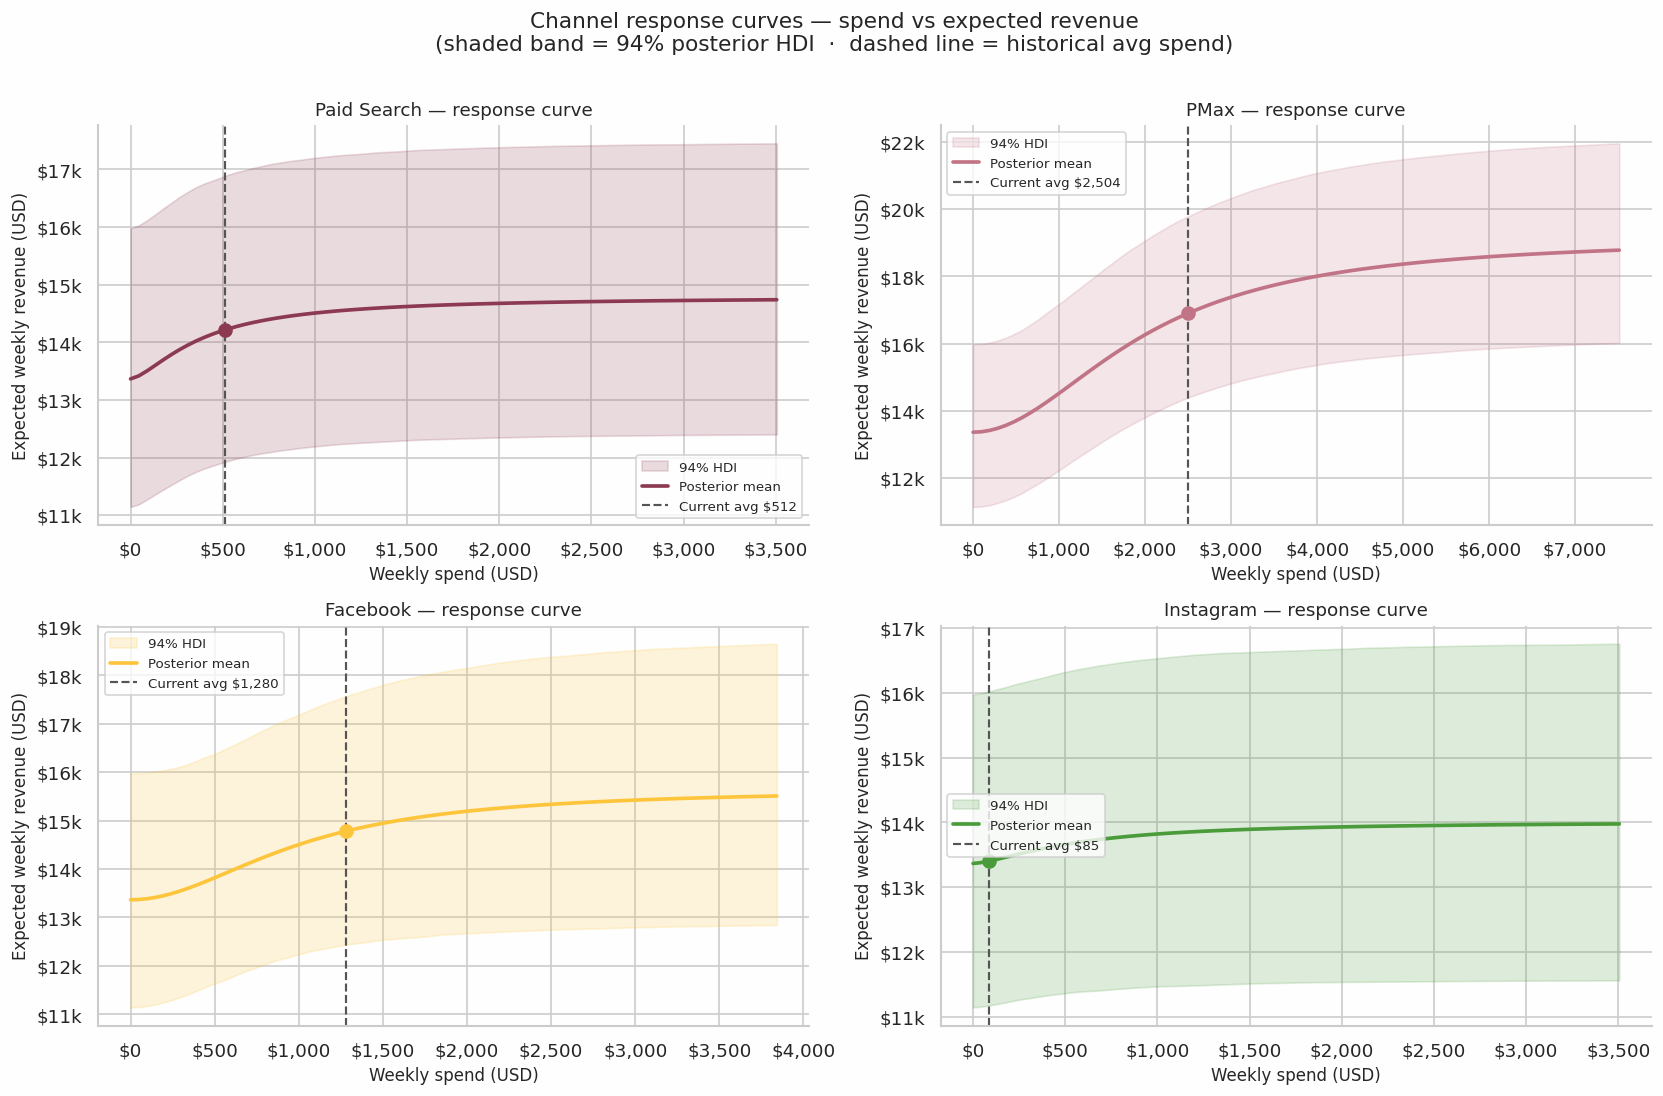

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

usd_fmt = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')

for ax, col, color in zip(axes, MEDIA_COLS, CHANNEL_COLORS.values()):
    rc       = response_curves[col]
    hist_avg = rc['hist_avg']

    ax.fill_between(rc['spend_grid'], rc['rev_lo'], rc['rev_hi'],
                    alpha=0.18, color=color, label='94% HDI')
    ax.plot(rc['spend_grid'], rc['rev_mean'],
            color=color, linewidth=2.2, label='Posterior mean')
    ax.axvline(hist_avg, color='#555555', linestyle='--', linewidth=1.3,
               label=f'Current avg ${hist_avg:,.0f}')

    rev_at_current = np.interp(hist_avg, rc['spend_grid'], rc['rev_mean'])
    ax.scatter([hist_avg], [rev_at_current], color=color, s=60, zorder=5)

    ax.xaxis.set_major_formatter(usd_fmt)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title(f'{MEDIA_LABELS[col]} — response curve')
    ax.set_xlabel('Weekly spend (USD)')
    ax.set_ylabel('Expected weekly revenue (USD)')
    ax.legend(fontsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'Channel response curves — spend vs expected revenue\n'
    '(shaded band = 94% posterior HDI  ·  dashed line = historical avg spend)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## 7.5. Marginal ROAS Curves

**Marginal ROAS (mROAS)** at spend level $s$ is the derivative of the response curve with respect to spend, numerically approximated via a central finite difference:

$$\text{mROAS}(s) \approx \frac{\text{Revenue}(s + \Delta s) - \text{Revenue}(s - \Delta s)}{2\,\Delta s}$$

The mROAS curve identifies **where each additional dollar generates the most return**. The **optimal budget allocation** occurs when mROAS equalizes across all channels — at that point, reallocating a dollar from any channel to another cannot increase total revenue.

The **horizontal dashed line** at mROAS = 1.0 marks the break-even threshold: spend levels to the right of this intersection destroy marginal value.

In [11]:
# ── Compute mROAS curves (central finite difference) ────────────────────────
mroas_curves = {}

for i, col in enumerate(MEDIA_COLS):
    rc      = response_curves[col]
    spend_g = rc['spend_grid']
    delta   = (spend_g[-1] - spend_g[0]) / (2 * N_POINTS)

    rev_fwd = np.zeros((n_samples, N_POINTS))
    rev_bwd = np.zeros((n_samples, N_POINTS))
    beta_ch = beta_media_flat[:, i]

    for j, s in enumerate(spend_g):
        rev_fwd[:, j] = channel_revenue_contribution(
            s + delta, col, beta_ch, intercept_flat, ctrl_mean, beta_ctrl_flat)
        rev_bwd[:, j] = channel_revenue_contribution(
            max(s - delta, 0), col, beta_ch, intercept_flat, ctrl_mean, beta_ctrl_flat)

    mroas_matrix = (rev_fwd - rev_bwd) / (2 * delta)
    mroas_mean   = mroas_matrix.mean(axis=0)
    mroas_lo     = np.percentile(mroas_matrix, 3,  axis=0)
    mroas_hi     = np.percentile(mroas_matrix, 97, axis=0)

    hist_avg         = rc['hist_avg']
    mroas_at_current = float(np.interp(hist_avg, spend_g, mroas_mean))

    mroas_curves[col] = {
        'spend_grid'      : spend_g,
        'mroas_mean'      : mroas_mean,
        'mroas_lo'        : mroas_lo,
        'mroas_hi'        : mroas_hi,
        'mroas_at_current': mroas_at_current,
        'hist_avg'        : hist_avg,
    }

print('mROAS at current spend (posterior mean):')
for col in MEDIA_COLS:
    m = mroas_curves[col]['mroas_at_current']
    print(f'  {MEDIA_LABELS[col]:<16}: mROAS = {m:.3f}')
print()
print('Channels ranked by mROAS (highest → reallocate TO):')
sorted_mroas = sorted(MEDIA_COLS, key=lambda c: mroas_curves[c]['mroas_at_current'], reverse=True)
for rank, col in enumerate(sorted_mroas, 1):
    m = mroas_curves[col]['mroas_at_current']
    print(f'  {rank}. {MEDIA_LABELS[col]:<16}: {m:.3f}')


mROAS at current spend (posterior mean):
  Paid Search     : mROAS = 1.007
  PMax            : mROAS = 1.103
  Facebook        : mROAS = 0.844
  Instagram       : mROAS = 0.588

Channels ranked by mROAS (highest → reallocate TO):
  1. PMax            : 1.103
  2. Paid Search     : 1.007
  3. Facebook        : 0.844
  4. Instagram       : 0.588


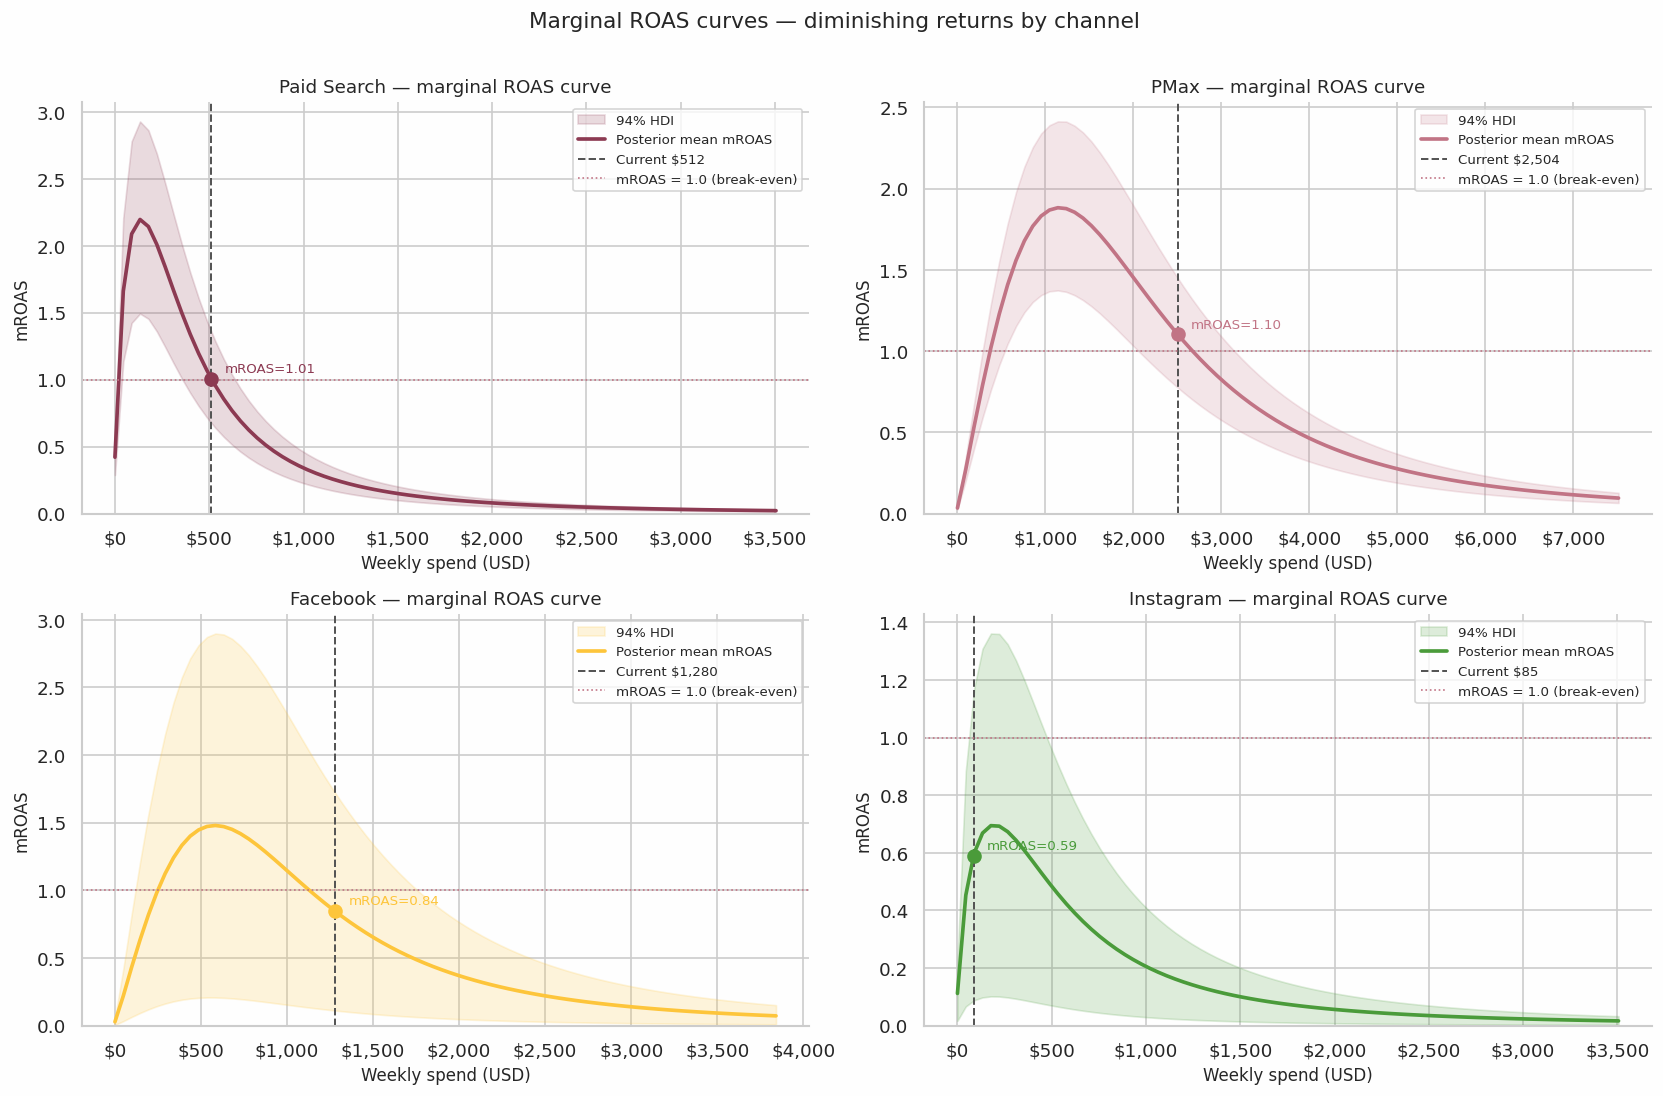

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col, color in zip(axes, MEDIA_COLS, CHANNEL_COLORS.values()):
    mc       = mroas_curves[col]
    hist_avg = mc['hist_avg']

    ax.fill_between(mc['spend_grid'], mc['mroas_lo'], mc['mroas_hi'],
                    alpha=0.18, color=color, label='94% HDI')
    ax.plot(mc['spend_grid'], mc['mroas_mean'],
            color=color, linewidth=2.2, label='Posterior mean mROAS')
    ax.axvline(hist_avg, color='#555555', linestyle='--', linewidth=1.2,
               label=f'Current ${hist_avg:,.0f}')
    ax.axhline(1.0, color=HB_COLORS['mauve_pink'], linestyle=':', linewidth=1.0,
               label='mROAS = 1.0 (break-even)')

    mroas_c = mc['mroas_at_current']
    ax.scatter([hist_avg], [mroas_c], color=color, s=60, zorder=5)
    ax.annotate(f'mROAS={mroas_c:.2f}', xy=(hist_avg, mroas_c),
                xytext=(8, 4), textcoords='offset points', fontsize=8, color=color)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_ylim(bottom=0)
    ax.set_title(f'{MEDIA_LABELS[col]} — marginal ROAS curve')
    ax.set_xlabel('Weekly spend (USD)')
    ax.set_ylabel('mROAS')
    ax.legend(fontsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('Marginal ROAS curves — diminishing returns by channel', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 7.5.1. mROAS overlay — all channels on a single axis

Plotting all four mROAS curves on a shared axis reveals at a glance which channels converge at the optimal λ (the Lagrange multiplier found in §7.6), and how far each channel's current spend deviates from the equalization point. Channels whose current spend (dashed vertical) lies to the **right** of the convergence zone are over-invested relative to the optimum; those to the **left** are under-invested.

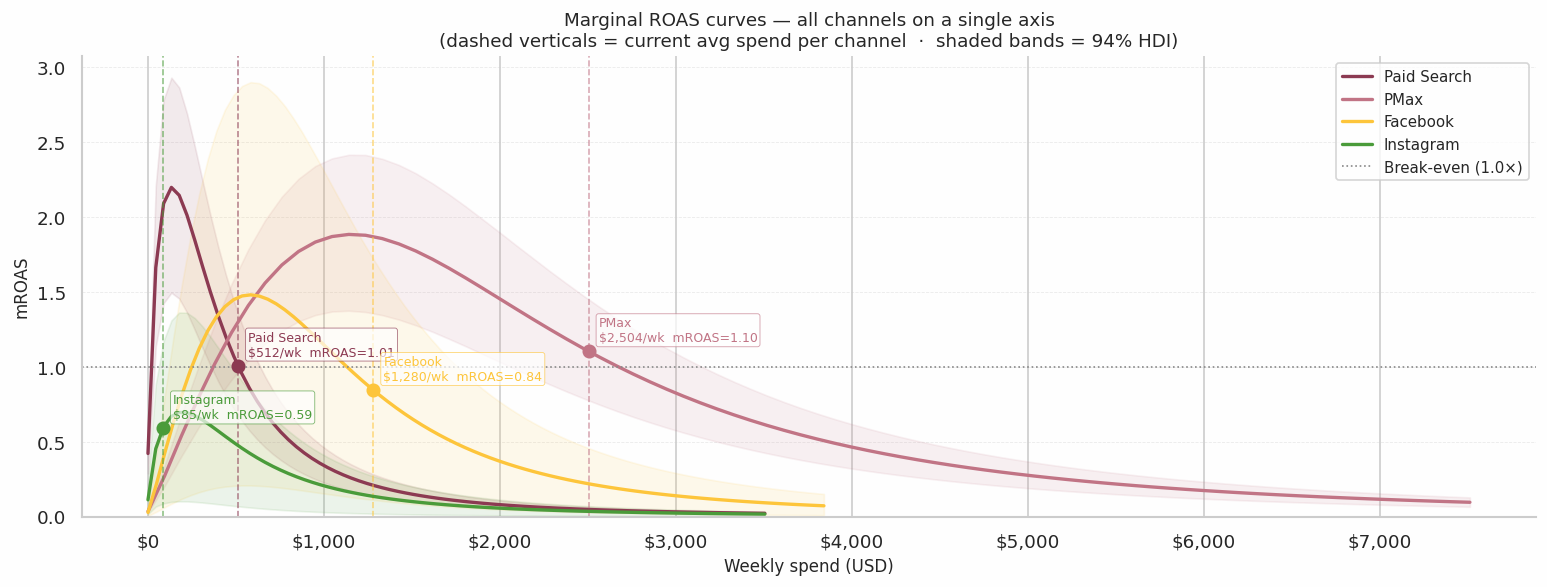

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

for col, color in CHANNEL_COLORS.items():
    mc       = mroas_curves[col]
    hist_avg = mc['hist_avg']
    label    = MEDIA_LABELS[col]

    ax.fill_between(mc['spend_grid'], mc['mroas_lo'], mc['mroas_hi'],
                    alpha=0.10, color=color)
    ax.plot(mc['spend_grid'], mc['mroas_mean'],
            color=color, linewidth=2.0, label=label)
    ax.axvline(hist_avg, color=color, linestyle='--', linewidth=1.0, alpha=0.6)

    mroas_c = mc['mroas_at_current']
    ax.scatter([hist_avg], [mroas_c], color=color, s=55, zorder=5)
    ax.annotate(
        f'{label}\n${hist_avg:,.0f}/wk  mROAS={mroas_c:.2f}',
        xy=(hist_avg, mroas_c),
        xytext=(6, 6), textcoords='offset points',
        fontsize=7.5, color=color,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec=color, lw=0.5),
    )

ax.axhline(1.0, color='#888888', linestyle=':', linewidth=1.0, label='Break-even (1.0×)')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(bottom=0)
ax.set_title(
    'Marginal ROAS curves — all channels on a single axis\n'
    '(dashed verticals = current avg spend per channel  ·  shaded bands = 94% HDI)',
    fontsize=11
)
ax.set_xlabel('Weekly spend (USD)')
ax.set_ylabel('mROAS')
ax.legend(fontsize=9, loc='upper right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

## 7.6. Analytical Optimization — mROAS Equalization

### 7.6.1. Theory

Under a fixed total budget $B$, revenue is maximized when marginal ROAS equalizes across all active channels:

$$\text{mROAS}_1(s_1^*) = \text{mROAS}_2(s_2^*) = \cdots = \text{mROAS}_C(s_C^*)$$

This follows from the Lagrangian of the constrained optimization problem. In practice:

1. Define a target mROAS $\lambda$ (the Lagrange multiplier).
2. For each channel, find the spend level $s_c^*$ such that $\text{mROAS}_c(s_c^*) = \lambda$.
3. Binary-search on $\lambda$ until $\sum_c s_c^* = B$, subject to per-channel bounds.

This approach is **interpretable** and **fast**, and provides an independent check on the numerical solution in §7.7. A large discrepancy between the two solutions would indicate non-convexity in the objective at the relevant spend levels.

In [14]:
def find_spend_for_target_mroas(
    target_mroas: float,
    channel_col: str,
    beta_samples: np.ndarray,
    spend_lo: float = 0,
    spend_hi: float = None,
    tol: float = 1e-2,
    max_iter: int = 100,
) -> float:
    """
    Binary search: find the spend level at which the posterior-mean mROAS
    equals target_mroas for a given channel. Returns spend in USD.
    """
    if spend_hi is None:
        spend_hi = WEEKLY_BUDGET_USD * 2.0

    rc         = mroas_curves[channel_col]
    sg         = rc['spend_grid']
    mroas_mean = rc['mroas_mean']

    if target_mroas < mroas_mean[-1]:
        return spend_hi
    if target_mroas > mroas_mean[0]:
        return spend_lo

    rev_mroas = mroas_mean[::-1]
    rev_spend = sg[::-1]
    return float(np.interp(target_mroas, rev_mroas, rev_spend))


def analytical_optimal_allocation(
    total_budget: float,
    beta_samples: np.ndarray = None,
    min_shares: dict = None,
    max_shares: dict = None,
    n_lambda_steps: int = 500,
) -> tuple:
    """
    Analytical mROAS equalization via binary search on lambda (target mROAS).
    Respects per-channel min/max share constraints.
    Returns (spend_dict, optimal_lambda).
    """
    min_shares = min_shares or MIN_SHARE
    max_shares = max_shares or MAX_SHARE

    min_spends = {col: total_budget * min_shares[col] for col in MEDIA_COLS}
    max_spends = {col: total_budget * max_shares[col] for col in MEDIA_COLS}

    def total_spend_at_lambda(lam):
        s_total = 0
        for col in MEDIA_COLS:
            s = find_spend_for_target_mroas(lam, col,
                                            beta_media_flat[:, MEDIA_COLS.index(col)])
            s = np.clip(s, min_spends[col], max_spends[col])
            s_total += s
        return s_total

    lam_lo, lam_hi = 0.001, 50.0
    for _ in range(100):
        lam_mid = (lam_lo + lam_hi) / 2
        if total_spend_at_lambda(lam_mid) > total_budget:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid
        if (lam_hi - lam_lo) < 1e-5:
            break

    optimal_lambda = (lam_lo + lam_hi) / 2
    optimal_spend  = {}
    for col in MEDIA_COLS:
        s = find_spend_for_target_mroas(optimal_lambda, col,
                                        beta_media_flat[:, MEDIA_COLS.index(col)])
        optimal_spend[col] = np.clip(s, min_spends[col], max_spends[col])

    total_allocated = sum(optimal_spend.values())
    if total_allocated > 0:
        scale = total_budget / total_allocated
        optimal_spend = {k: v * scale for k, v in optimal_spend.items()}

    return optimal_spend, optimal_lambda


# ── Run analytical optimization at reference budget ──────────────────────────
opt_spend_analytical, opt_lambda = analytical_optimal_allocation(WEEKLY_BUDGET_USD)

print(f'Reference weekly budget  : ${WEEKLY_BUDGET_USD:,.0f}')
print(f'Optimal lambda (mROAS)   : {opt_lambda:.4f}')
print()
print(f'{"Channel":<16}  {"Current ($)":>12}  {"Optimal ($)":>12}  {"Change ($)":>11}  {"Change %":>9}')
print('-' * 70)
for col in MEDIA_COLS:
    raw_col  = SPEND_COL_MAP[col]
    curr     = df_clean[raw_col].mean() if raw_col in df_clean.columns else WEEKLY_BUDGET_USD * hist_shares_pct[col]
    opt      = opt_spend_analytical[col]
    delta    = opt - curr
    pct      = delta / curr * 100 if curr > 0 else float('nan')
    arrow    = '↑' if delta > 0 else '↓'
    print(f'{MEDIA_LABELS[col]:<16}  {curr:>12,.0f}  {opt:>12,.0f}  {delta:>+11,.0f}  {arrow}{abs(pct):>7.1f}%')

print('-' * 70)
curr_total = sum(df_clean[SPEND_COL_MAP[col]].mean() for col in MEDIA_COLS if SPEND_COL_MAP[col] in df_clean.columns)
opt_total  = sum(opt_spend_analytical.values())
print(f'{"TOTAL":<16}  {curr_total:>12,.0f}  {opt_total:>12,.0f}')


Reference weekly budget  : $4,382
Optimal lambda (mROAS)   : 0.0949

Channel            Current ($)   Optimal ($)   Change ($)   Change %
----------------------------------------------------------------------
Paid Search                512         1,345         +833  ↑  162.7%
PMax                     2,504         1,918         -586  ↓   23.4%
Facebook                 1,280           160       -1,121  ↓   87.5%
Instagram                   85           959         +874  ↑ 1022.7%
----------------------------------------------------------------------
TOTAL                    4,382         4,382


## 7.7. Numerical Optimization — SLSQP

### 7.7.1. Formulation

The numerical optimizer solves:

$$\max_{s_1, \ldots, s_C} \; \sum_c \text{Revenue}_c(s_c) \quad \text{subject to} \quad \sum_c s_c = B,\quad s_{c,\min} \leq s_c \leq s_{c,\max}$$

We use **SLSQP** (Sequential Least Squares Programming) — a gradient-based method suited for smooth nonlinear objectives with equality and bound constraints. The objective uses the **posterior mean** response for speed; uncertainty is propagated separately across all six scenarios in §7.8.

The analytical mROAS equalization solution (§7.6) provides a warm-start for SLSQP, typically achieving convergence in fewer than 20 iterations. Multiple random restarts guard against convergence to a local optimum.

> A **Differential Evolution** fallback is available via `numerical_optimal_allocation(..., use_de=True)` for pathological non-convex cases, but is not required in standard operation.

In [15]:
def weekly_expected_revenue(spend_vec: np.ndarray) -> float:
    """
    Total expected revenue (USD) for a given spend vector.
    Uses posterior mean beta — fast, suitable for scipy optimization.
    """
    beta_mean         = beta_media_flat.mean(axis=0)
    ctrl_mean_contrib = (beta_ctrl_flat.mean(axis=0) * ctrl_mean).sum()
    intercept_mean    = float(intercept_flat.mean())
    # Include the Model B linear time trend at the temporal midpoint
    trend_contrib     = float(beta_trend_flat.mean()) * t_mean

    total_rev = 0.0
    for i, col in enumerate(MEDIA_COLS):
        raw_col  = SPEND_COL_MAP[col].replace('spend_', '')
        full_raw = 'spend_' + raw_col
        decay    = ADSTOCK_PARAMS.get(full_raw, 0.3)
        alpha    = HILL_ALPHA.get(full_raw, 1.5)
        K        = HILL_K[col]

        ads   = geometric_adstock_scalar(spend_vec[i], decay)
        hill  = hill_saturation(ads, alpha, K)
        cal_factor = CALIBRATION_FACTORS.get(col, 1.0)
        total_rev += beta_mean[i] * cal_factor * hill

    log_rev_total = intercept_mean + total_rev + ctrl_mean_contrib + trend_contrib
    return np.exp(log_rev_total)


def neg_revenue(spend_vec):
    """Negated objective for minimization."""
    return -weekly_expected_revenue(spend_vec)


def neg_revenue_grad(spend_vec):
    """Numerical gradient via central finite differences."""
    eps = 1.0
    g   = np.zeros(len(spend_vec))
    for k in range(len(spend_vec)):
        s_fwd = spend_vec.copy(); s_fwd[k] += eps
        s_bwd = spend_vec.copy(); s_bwd[k] -= eps
        g[k]  = (-weekly_expected_revenue(s_fwd) + weekly_expected_revenue(s_bwd)) / (2 * eps)
    return g


def numerical_optimal_allocation(
    total_budget: float,
    min_shares: dict = None,
    max_shares: dict = None,
    n_restarts: int = 5,
    use_de: bool = False,
    x0_warm: dict = None,
) -> dict:
    """
    Constrained numerical optimization via SLSQP with multiple random restarts.

    Parameters
    ----------
    total_budget : float
        Total weekly budget in USD.
    min_shares / max_shares : dict
        Per-channel allocation bounds as share of total budget.
    n_restarts : int
        Number of random starting points (in addition to the analytical warm-start).
    use_de : bool
        If True, use Differential Evolution instead of SLSQP. Slower but global.
        Default: False.
    x0_warm : dict, optional
        Warm-start spend allocation {col: spend}. If None, the analytical mROAS
        equalization solution is computed internally for this budget.
    """
    min_shares = min_shares or MIN_SHARE
    max_shares = max_shares or MAX_SHARE

    bounds = [
        (total_budget * min_shares[col], total_budget * max_shares[col])
        for col in MEDIA_COLS
    ]
    constraints = [{
        'type': 'eq',
        'fun' : lambda s: s.sum() - total_budget,
        'jac' : lambda s: np.ones(len(s)),
    }]

    if use_de:
        from scipy.optimize import differential_evolution
        def neg_rev_de(s):
            s_norm = s / s.sum() * total_budget
            return neg_revenue(s_norm)
        de_result = differential_evolution(neg_rev_de, bounds, seed=42, maxiter=500, tol=1e-8)
        x_opt = de_result.x / de_result.x.sum() * total_budget
        return {col: float(x_opt[i]) for i, col in enumerate(MEDIA_COLS)}

    # ── SLSQP with multiple restarts ────────────────────────────────────────
    # Warm-start: use provided x0 or compute analytical solution for this budget
    if x0_warm is not None:
        _ws = np.array([x0_warm[col] for col in MEDIA_COLS])
    else:
        _ws_dict, _ = analytical_optimal_allocation(total_budget, min_shares=min_shares, max_shares=max_shares)
        _ws = np.array([_ws_dict[col] for col in MEDIA_COLS])
    x0_analytical = np.clip(_ws, [b[0] for b in bounds], [b[1] for b in bounds])
    x0_analytical = x0_analytical / x0_analytical.sum() * total_budget

    # Random starting points
    rng = np.random.default_rng(42)
    starting_points = [x0_analytical]
    for _ in range(n_restarts - 1):
        x_rand = rng.uniform([b[0] for b in bounds], [b[1] for b in bounds])
        x_rand = x_rand / x_rand.sum() * total_budget
        starting_points.append(x_rand)

    best_result = None
    best_revenue = -np.inf
    for x0 in starting_points:
        res = minimize(
            neg_revenue,
            x0,
            jac=neg_revenue_grad,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-9, 'maxiter': 1000, 'disp': False},
        )
        rev = -res.fun if res.success else -np.inf
        if rev > best_revenue:
            best_revenue = rev
            best_result  = res

    if best_result is None or not best_result.success:
        print(f'⚠  SLSQP did not converge. Using analytical warm-start as fallback.')
        fallback, _ = analytical_optimal_allocation(total_budget, min_shares=min_shares, max_shares=max_shares)
        return fallback

    return {col: float(best_result.x[i]) for i, col in enumerate(MEDIA_COLS)}


# ── Run numerical optimization ───────────────────────────────────────────────
opt_spend_numerical = numerical_optimal_allocation(WEEKLY_BUDGET_USD)

print('NUMERICAL vs ANALYTICAL SOLUTION COMPARISON')
print(f'  Budget: ${WEEKLY_BUDGET_USD:,.0f}/week')
print()
print(f'{"Channel":<16}  {"Analytical ($)":>15}  {"Numerical ($)":>15}  {"Diff ($)":>10}')
print('-' * 62)
for col in MEDIA_COLS:
    a = opt_spend_analytical[col]
    n = opt_spend_numerical[col]
    d = n - a
    print(f'{MEDIA_LABELS[col]:<16}  {a:>15,.0f}  {n:>15,.0f}  {d:>+10,.0f}')

print('-' * 62)
print(f'{"TOTAL":<16}  {sum(opt_spend_analytical.values()):>15,.0f}  {sum(opt_spend_numerical.values()):>15,.0f}')
print()

rev_analytical = weekly_expected_revenue(np.array([opt_spend_analytical[c] for c in MEDIA_COLS]))
rev_numerical  = weekly_expected_revenue(np.array([opt_spend_numerical[c]  for c in MEDIA_COLS]))
print(f'Expected weekly revenue — Analytical: ${rev_analytical:,.0f}   Numerical: ${rev_numerical:,.0f}')

BEST_OPT = opt_spend_numerical if rev_numerical >= rev_analytical else opt_spend_analytical
METHOD   = 'Numerical (SLSQP)' if rev_numerical >= rev_analytical else 'Analytical (mROAS equalization)'
print(f'Selected solution             : {METHOD}')


NUMERICAL vs ANALYTICAL SOLUTION COMPARISON
  Budget: $4,382/week

Channel            Analytical ($)    Numerical ($)    Diff ($)
--------------------------------------------------------------
Paid Search                 1,345              538        -807
PMax                        1,918            2,478        +560
Facebook                      160            1,147        +987
Instagram                     959              219        -740
--------------------------------------------------------------
TOTAL                       4,382            4,382

Expected weekly revenue — Analytical: $18,230   Numerical: $19,850
Selected solution             : Numerical (SLSQP)


## 7.8. Scenario Simulation

### 7.8.1. Scenario definitions

Six concrete scenarios are simulated, each with a distinct allocation strategy:

| # | Scenario | Budget | Allocation logic |
|:--|:---------|:-------|:-----------------|
| 1 | **Base** | Historical mean | Historical channel mix (as-is) |
| 2 | **Optimized (same budget)** | Historical mean | Optimal allocation via SLSQP |
| 3 | **+20% budget** | +20% | Optimal allocation at increased budget |
| 4 | **−20% budget** | −20% | Optimal allocation at reduced budget |
| 5 | **Pure reallocation** | Historical mean | Optimal mix, no extra spend |
| 6 | **Aggressive top-2** | Historical mean | 80% to top-2 mROAS channels |

> **Uncertainty:** Each scenario reports the posterior-mean expected revenue plus a 94% HDI propagated from the full posterior distribution. Each recommendation is assigned a confidence level (HIGH / MEDIUM / LOW) based on the posterior probability that the scenario outperforms the base.

In [16]:
def simulate_scenario(
    scenario_name: str,
    spend_dict: dict,
    description: str = '',
) -> dict:
    """
    Simulate expected revenue for a given spend allocation.
    Propagates uncertainty across all posterior samples.
    Returns a result dict with mean, HDI and per-channel metrics.
    """
    spend_vec = np.array([spend_dict[col] for col in MEDIA_COLS])

    rev_samples = np.zeros(n_samples)
    for idx in range(n_samples):
        b_m    = beta_media_flat[idx]
        b_c    = beta_ctrl_flat[idx]
        intcp  = intercept_flat[idx]
        b_tr   = beta_trend_flat[idx]
        ctrl_c = (b_c * ctrl_mean).sum()
        # Include the Model B linear time trend at the temporal midpoint
        log_rev = intcp + ctrl_c + b_tr * t_mean
        for i, col in enumerate(MEDIA_COLS):
            raw_col  = SPEND_COL_MAP[col].replace('spend_', '')
            full_raw = 'spend_' + raw_col
            decay    = ADSTOCK_PARAMS.get(full_raw, 0.3)
            alpha    = HILL_ALPHA.get(full_raw, 1.5)
            K        = HILL_K[col]
            ads      = geometric_adstock_scalar(spend_vec[i], decay)
            hill     = hill_saturation(ads, alpha, K)
            cal_factor = CALIBRATION_FACTORS.get(col, 1.0)
            log_rev += b_m[i] * cal_factor * hill
        rev_samples[idx] = np.exp(log_rev)

    hdi         = az.hdi(rev_samples, hdi_prob=0.94)
    total_spend = sum(spend_dict.values())

    return {
        'name'        : scenario_name,
        'description' : description,
        'spend'       : spend_dict.copy(),
        'total_spend' : total_spend,
        'rev_mean'    : float(rev_samples.mean()),
        'rev_median'  : float(np.median(rev_samples)),
        'rev_hdi_lo'  : float(hdi[0]),
        'rev_hdi_hi'  : float(hdi[1]),
        'roas_mean'   : float(rev_samples.mean() / total_spend) if total_spend > 0 else 0,
        'rev_samples' : rev_samples,
    }


In [17]:
# ── Build scenario spend allocations ────────────────────────────────────────
hist_spend = {
    col: (
        df_clean[SPEND_COL_MAP[col]].mean()
        if SPEND_COL_MAP[col] in df_clean.columns
        else WEEKLY_BUDGET_USD * hist_shares_pct[col]
    )
    for col in MEDIA_COLS
}

budget_base = WEEKLY_BUDGET_USD
budget_up20 = WEEKLY_BUDGET_USD * 1.20
budget_dn20 = WEEKLY_BUDGET_USD * 0.80

# Aggressive top-2 scenario
top2_cols    = sorted(MEDIA_COLS, key=lambda c: mroas_curves[c]['mroas_at_current'], reverse=True)[:2]
bottom2_cols = [c for c in MEDIA_COLS if c not in top2_cols]

aggressive_spend = {}
for col in MEDIA_COLS:
    if col in top2_cols:
        aggressive_spend[col] = budget_base * 0.40
    else:
        aggressive_spend[col] = budget_base * 0.10

print(f'Aggressive top-2 channels: {" + ".join(MEDIA_LABELS[c] for c in top2_cols)}')
print(f'Bottom-2 channels        : {" + ".join(MEDIA_LABELS[c] for c in bottom2_cols)}')
print()

# ── Run all scenarios ────────────────────────────────────────────────────────
print('Simulating scenarios...')

scenarios = [
    simulate_scenario(
        'Base (historical)', hist_spend,
        'Historical channel mix at actual average weekly spend'
    ),
    simulate_scenario(
        'Optimized (same budget)', numerical_optimal_allocation(budget_base),
        'Optimal allocation at same total budget (SLSQP)'
    ),
    simulate_scenario(
        '+20% budget', numerical_optimal_allocation(budget_up20),
        f'Optimal allocation with 20% budget increase (${budget_up20:,.0f}/week)'
    ),
    simulate_scenario(
        '-20% budget', numerical_optimal_allocation(budget_dn20),
        f'Optimal allocation with 20% budget reduction (${budget_dn20:,.0f}/week)'
    ),
    simulate_scenario(
        'Pure reallocation', BEST_OPT,
        'Optimal channel mix at same budget — reallocation only, no extra spend'
    ),
    simulate_scenario(
        'Aggressive top-2', aggressive_spend,
        f'80% budget concentrated in top-2 mROAS channels ({" + ".join(MEDIA_LABELS[c] for c in top2_cols)})'
    ),
]

print()
print(f'{"Scenario":<28}  {"Budget/wk":>10}  {"Rev/wk (mean)":>14}  {"ROAS":>6}  {"HDI 94%":>22}')
print('-' * 90)
base_rev = scenarios[0]['rev_mean']
for sc in scenarios:
    uplift  = (sc['rev_mean'] - base_rev) / base_rev * 100
    hdi_str = f'[{sc["rev_hdi_lo"]:,.0f} – {sc["rev_hdi_hi"]:,.0f}]'
    print(f'{sc["name"]:<28}  ${sc["total_spend"]:>9,.0f}  ${sc["rev_mean"]:>13,.0f}  {sc["roas_mean"]:>6.2f}  {hdi_str:>22}  ({uplift:>+.1f}% vs base)')


Aggressive top-2 channels: PMax + Paid Search
Bottom-2 channels        : Facebook + Instagram

Simulating scenarios...

Scenario                       Budget/wk   Rev/wk (mean)    ROAS                 HDI 94%
------------------------------------------------------------------------------------------
Base (historical)             $    4,382  $       19,928    4.55       [17,266 – 22,552]  (+0.0% vs base)
Optimized (same budget)       $    4,382  $       19,898    4.54       [17,405 – 22,633]  (-0.2% vs base)
+20% budget                   $    5,259  $       20,916    3.98       [18,225 – 23,659]  (+5.0% vs base)
-20% budget                   $    3,506  $       18,621    5.31       [16,147 – 21,187]  (-6.6% vs base)
Pure reallocation             $    4,382  $       19,898    4.54       [17,405 – 22,633]  (-0.2% vs base)
Aggressive top-2              $    4,382  $       18,234    4.16       [15,778 – 20,899]  (-8.5% vs base)


### 7.8.2. Scenario comparison — revenue and uplift

The left panel shows absolute expected weekly revenue with 94% posterior HDI. The right panel shows **revenue delta vs the historical base** — the figure that directly answers the business question: *how much more (or less) revenue does each scenario generate relative to doing nothing?* Confidence labels (HIGH / MEDIUM / LOW) reflect the posterior probability that each scenario outperforms the base.

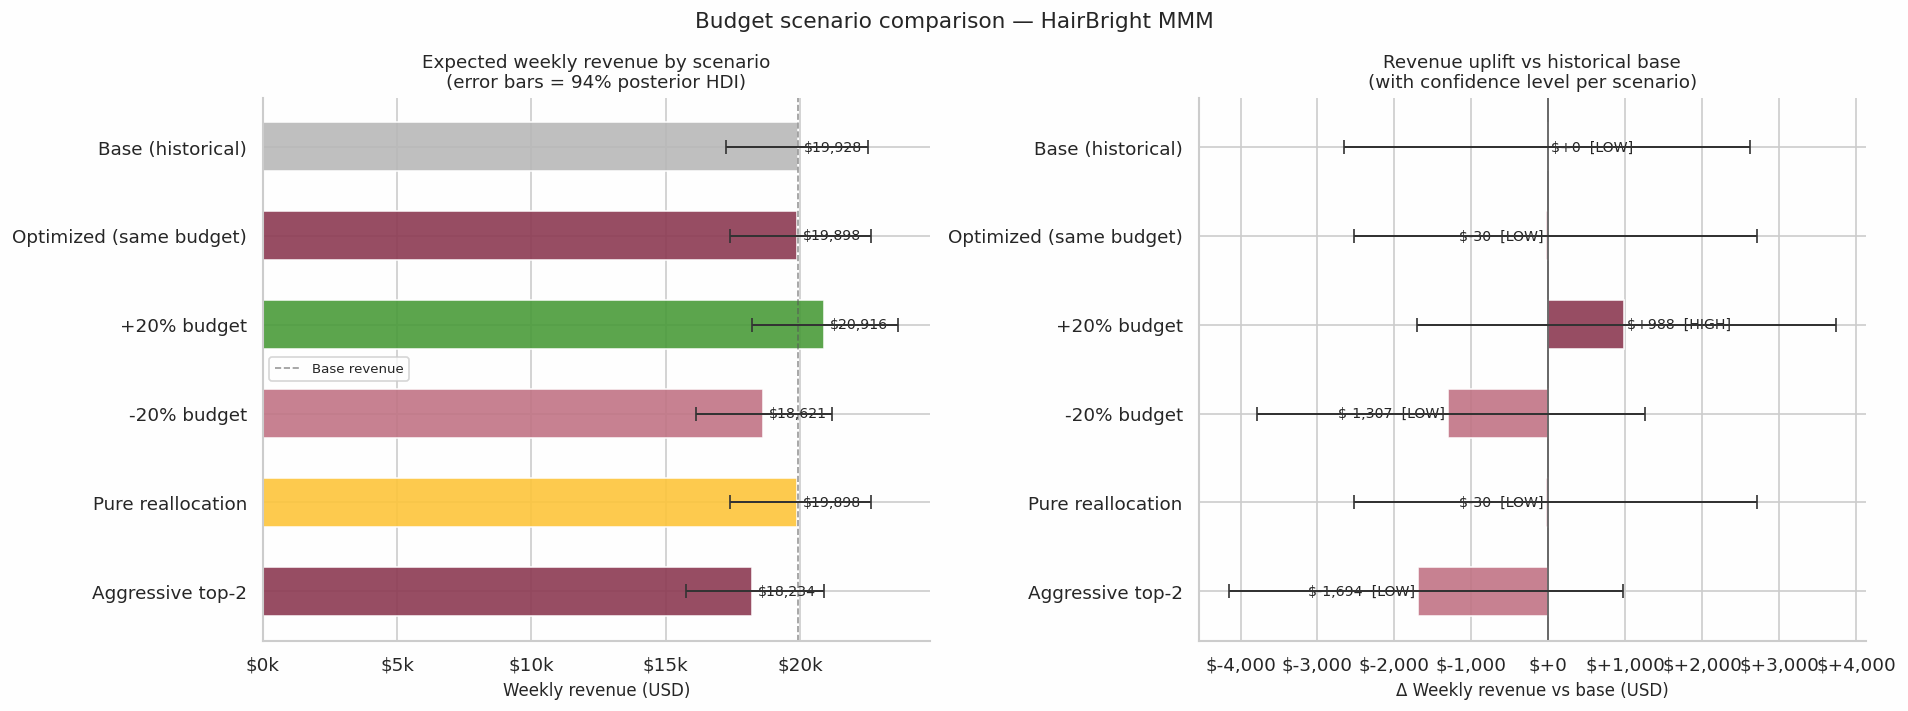

In [18]:
base_rev_sc = scenarios[0]['rev_mean']

sc_names   = [sc['name'] for sc in scenarios]
rev_means  = [sc['rev_mean'] for sc in scenarios]
err_lo     = [sc['rev_mean'] - sc['rev_hdi_lo'] for sc in scenarios]
err_hi     = [sc['rev_hdi_hi'] - sc['rev_mean'] for sc in scenarios]
deltas     = [sc['rev_mean'] - base_rev_sc for sc in scenarios]
delta_lo   = [sc['rev_mean'] - sc['rev_hdi_lo'] for sc in scenarios]
delta_hi   = [sc['rev_hdi_hi'] - sc['rev_mean'] for sc in scenarios]

def _conf_label(sc):
    p = float(np.mean(sc['rev_samples'] > scenarios[0]['rev_samples']))
    if p >= 0.90: return 'HIGH'
    if p >= 0.70: return 'MEDIUM'
    return 'LOW'

sc_colors = [
    '#B8B8B8',              # Base — neutral grey
    HB_COLORS['deep_mauve'],  # Optimized — primary brand
    '#4A9B3A',              # +20%  — green
    HB_COLORS['mauve_pink'],  # -20%  — muted
    HB_COLORS['amber_gold'],  # Pure reallocation
    HB_COLORS['deep_mauve'],  # Aggressive top-2
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: absolute weekly revenue ─────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(sc_names, rev_means, color=sc_colors, edgecolor='white', alpha=0.90, height=0.55)
ax.errorbar(rev_means, sc_names, xerr=[err_lo, err_hi],
            fmt='none', color='#333333', capsize=4, linewidth=1.2, zorder=5)
ax.axvline(base_rev_sc, color='#555555', linestyle='--', linewidth=1.0, alpha=0.6, label='Base revenue')
for bar, val in zip(bars, rev_means):
    ax.text(val + max(rev_means) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Expected weekly revenue by scenario\n(error bars = 94% posterior HDI)')
ax.set_xlabel('Weekly revenue (USD)')
ax.legend(fontsize=8)
ax.invert_yaxis()
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# ── Right: revenue delta vs base ──────────────────────────────────────────────
ax = axes[1]
delta_colors = [
    '#B8B8B8' if d == 0
    else HB_COLORS['deep_mauve'] if d > 0
    else HB_COLORS['mauve_pink']
    for d in deltas
]
bars2 = ax.barh(sc_names, deltas, color=delta_colors, edgecolor='white', alpha=0.90, height=0.55)
ax.errorbar(deltas, sc_names, xerr=[delta_lo, delta_hi],
            fmt='none', color='#333333', capsize=4, linewidth=1.2, zorder=5)
ax.axvline(0, color='#555555', linewidth=1.0)

for bar, val, sc in zip(bars2, deltas, scenarios):
    conf  = _conf_label(sc)
    x_pos = val + max(abs(d) for d in deltas) * 0.02 if val >= 0 else val - max(abs(d) for d in deltas) * 0.02
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'${val:+,.0f}  [{conf}]', va='center', ha=ha, fontsize=8.5)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.set_title('Revenue uplift vs historical base\n(with confidence level per scenario)')
ax.set_xlabel('Δ Weekly revenue vs base (USD)')
ax.invert_yaxis()
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.suptitle('Budget scenario comparison — HairBright MMM', fontsize=13)
plt.tight_layout()
plt.show()

### 7.8.3. Channel allocation heatmap

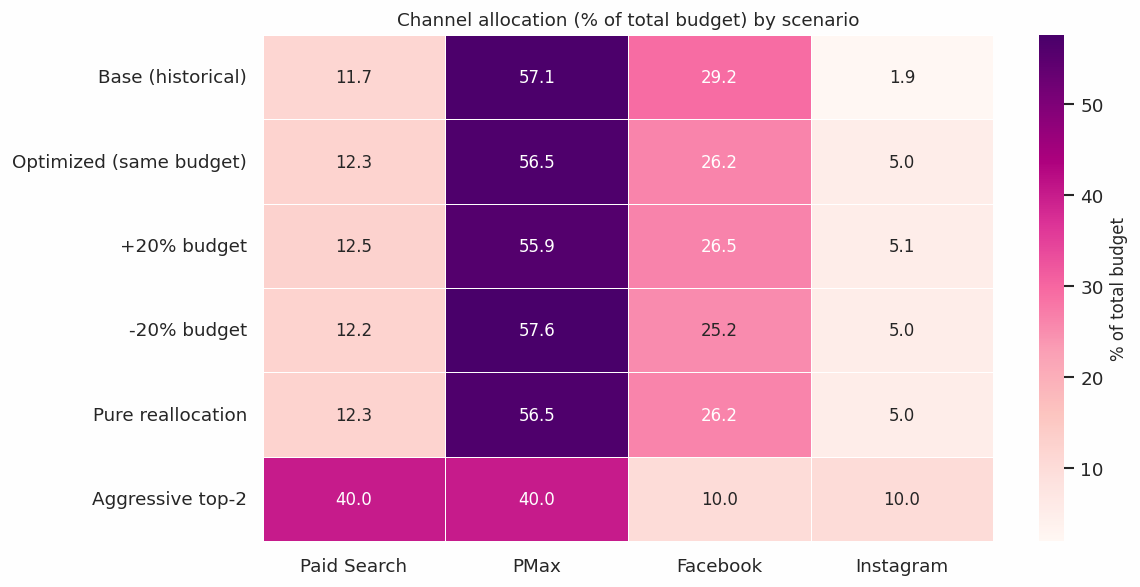


Note: rows sum to 100% within each scenario.


In [19]:
# Build allocation matrix (scenarios × channels)
alloc_matrix = np.zeros((len(scenarios), len(MEDIA_COLS)))
for i, sc in enumerate(scenarios):
    total = sc['total_spend']
    for j, col in enumerate(MEDIA_COLS):
        alloc_matrix[i, j] = sc['spend'][col] / total * 100 if total > 0 else 0

df_heatmap = pd.DataFrame(
    alloc_matrix,
    index=[sc['name'] for sc in scenarios],
    columns=[MEDIA_LABELS[c] for c in MEDIA_COLS]
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    df_heatmap,
    annot=True, fmt='.1f', cmap='RdPu',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of total budget'},
    ax=ax
)
ax.set_title('Channel allocation (% of total budget) by scenario')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print()
print('Note: rows sum to 100% within each scenario.')


## 7.9. Revenue Uplift — Channel Waterfall

**What:** Decomposes the revenue gain of the optimized scenario (same budget) relative to the historical base into per-channel contributions.

**Why:** Identifying *which channel reallocation drives the most uplift* is essential for communicating the optimization rationale to channel owners and media teams — it shows not just the total gain but where it comes from.

For each channel, the bar shows the weekly revenue gained (green) or lost (red) by shifting from the historical to the optimal allocation. The per-channel deltas are computed using the exact exp() formula rather than a linear approximation, which becomes inaccurate for large log-revenue deltas:

$$\Delta \text{Rev}_c = \text{Rev}_{\text{base}} \cdot \left(e^{\Delta \log\text{rev}_c} - 1\right)$$

The sum of all channel deltas approximates the total weekly uplift.

In [20]:
base_sc = scenarios[0]
opt_sc  = scenarios[1]   # Optimized (same budget)

beta_mean = beta_media_flat.mean(axis=0)
ctrl_c    = (beta_ctrl_flat.mean(axis=0) * ctrl_mean).sum()
intcp_m   = float(intercept_flat.mean())


def channel_rev_at_spend(spend_val, col):
    """Log-revenue contribution of a channel at a given spend level."""
    i        = MEDIA_COLS.index(col)
    raw_col  = SPEND_COL_MAP[col].replace('spend_', '')
    full_raw = 'spend_' + raw_col
    decay    = ADSTOCK_PARAMS.get(full_raw, 0.3)
    alpha    = HILL_ALPHA.get(full_raw, 1.5)
    K        = HILL_K[col]
    ads      = geometric_adstock_scalar(spend_val, decay)
    hill     = hill_saturation(ads, alpha, K)
    # Apply calibration factor (consistent with simulate_scenario)
    cal_factor = CALIBRATION_FACTORS.get(col, 1.0)
    return beta_mean[i] * cal_factor * hill   # contribution to log-revenue


waterfall_data = []
for col in MEDIA_COLS:
    contrib_base = channel_rev_at_spend(base_sc['spend'][col], col)
    contrib_opt  = channel_rev_at_spend(opt_sc['spend'][col],  col)
    base_rev_usd = base_sc['rev_mean']
    # Use the exact exp() formula rather than a linear approximation,
    # which is only accurate for small log-revenue deltas.
    delta_log    = contrib_opt - contrib_base
    delta_rev    = base_rev_usd * (np.exp(delta_log) - 1)
    waterfall_data.append({
        'channel'      : MEDIA_LABELS[col],
        'spend_base'   : base_sc['spend'][col],
        'spend_opt'    : opt_sc['spend'][col],
        'delta_spend'  : opt_sc['spend'][col] - base_sc['spend'][col],
        'delta_rev_usd': delta_rev,
    })

df_waterfall = pd.DataFrame(waterfall_data)
total_delta  = opt_sc['rev_mean'] - base_sc['rev_mean']

print(f'Total expected weekly revenue uplift (optimized vs base): ${total_delta:+,.0f}')
print()
print(df_waterfall[['channel', 'spend_base', 'spend_opt', 'delta_spend', 'delta_rev_usd']]
      .rename(columns={
          'spend_base'  : 'Base spend ($)',
          'spend_opt'   : 'Opt spend ($)',
          'delta_spend' : 'Δ Spend ($)',
          'delta_rev_usd': 'Δ Revenue ($)',
      }).to_string(index=False))


Total expected weekly revenue uplift (optimized vs base): $-30

    channel  Base spend ($)  Opt spend ($)  Δ Spend ($)  Δ Revenue ($)
Paid Search      512.027460     537.735589    25.708129      35.204586
       PMax     2504.218470    2478.019298   -26.199172     -34.351204
   Facebook     1280.479252    1147.289182  -133.190071    -162.231189
  Instagram       85.426468     219.107583   133.681114     132.861320


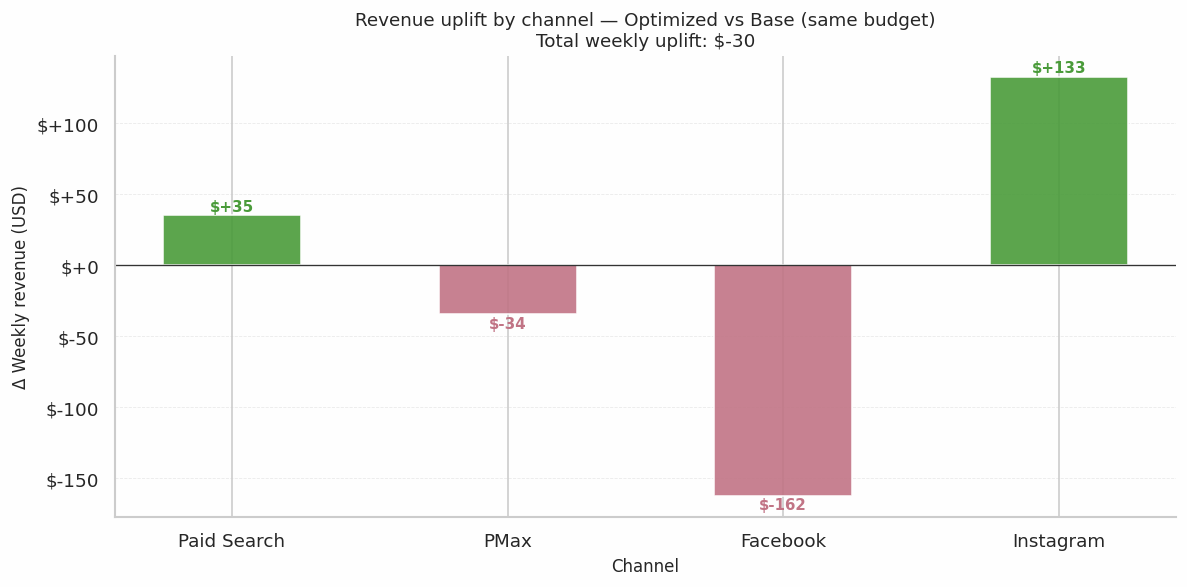

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

channels_wf = [d['channel'] for d in waterfall_data]
deltas_rev  = [d['delta_rev_usd'] for d in waterfall_data]
colors_wf   = ['#4A9B3A' if d >= 0 else HB_COLORS['mauve_pink'] for d in deltas_rev]

bars = ax.bar(channels_wf, deltas_rev, color=colors_wf, edgecolor='white', alpha=0.90, width=0.5)
ax.axhline(0, color='#333333', linewidth=0.8)

abs_max = max(abs(v) for v in deltas_rev) if deltas_rev else 1
for bar, val in zip(bars, deltas_rev):
    ypos = (bar.get_height() + abs_max * 0.02) if val >= 0 else (bar.get_height() - abs_max * 0.06)
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'${val:+,.0f}', ha='center', fontsize=9, fontweight='bold',
            color='#4A9B3A' if val >= 0 else HB_COLORS['mauve_pink'])

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax.set_title(
    f'Revenue uplift by channel — Optimized vs Base (same budget)\n'
    f'Total weekly uplift: ${total_delta:+,.0f}'
)
ax.set_xlabel('Channel')
ax.set_ylabel('Δ Weekly revenue (USD)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

## 7.10. Optimization Uncertainty

**What:** Distribution of expected weekly revenue across all posterior samples for the base and optimized scenarios.

**Why:** The optimizer uses the posterior mean β to find the optimal allocation, but model parameter uncertainty translates directly into uncertainty in the revenue promise of that allocation. This section quantifies that uncertainty and answers: *how confident are we that the optimized scenario outperforms the base?*

The probability P(optimized > base) is computed from the full posterior: the fraction of samples where the optimized allocation generates higher revenue than the historical allocation.

P(optimized > base)                : 40.3%
Expected weekly revenue uplift     : $-30
94% HDI of uplift                  : [$-231, $+174]
Annual uplift (× 52 weeks)         : $-1,579


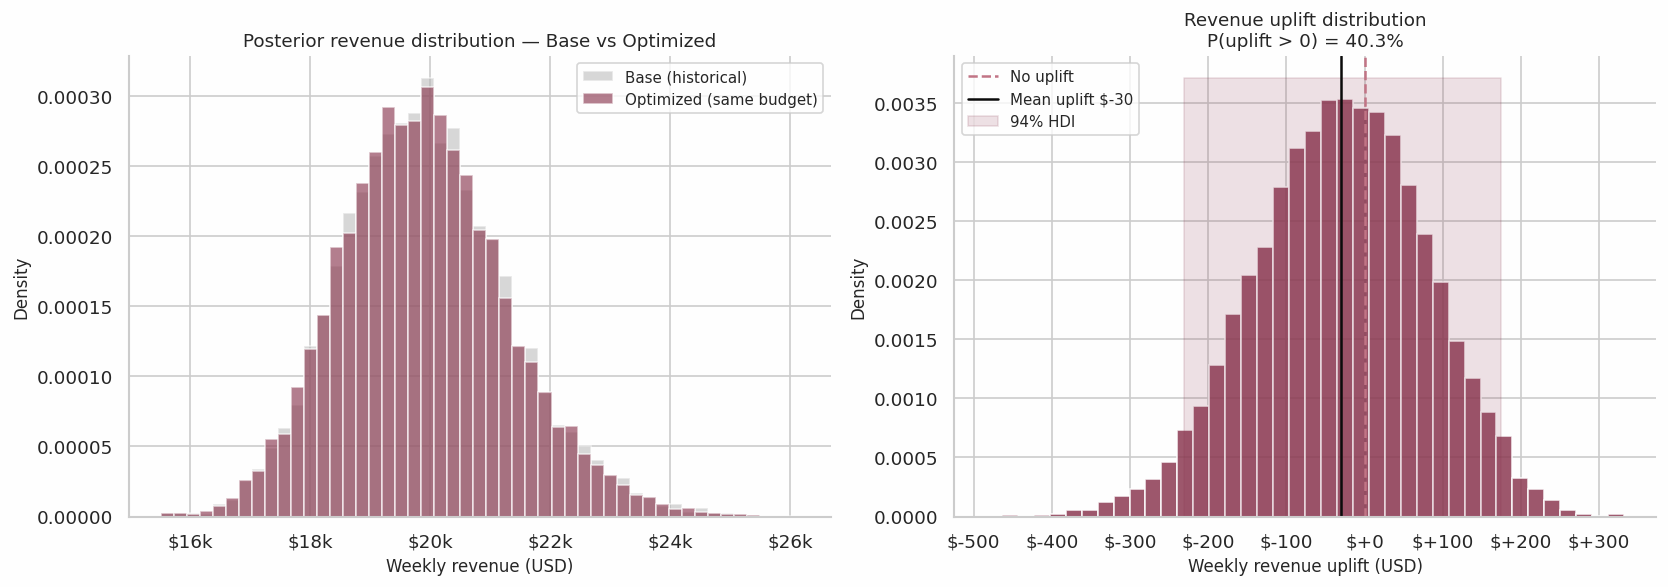

In [22]:
base_samples  = scenarios[0]['rev_samples']
opt_samples   = scenarios[1]['rev_samples']

prob_better   = float(np.mean(opt_samples > base_samples))
delta_samples = opt_samples - base_samples
delta_mean    = float(delta_samples.mean())
delta_hdi     = az.hdi(delta_samples, hdi_prob=0.94)

print(f'P(optimized > base)                : {prob_better*100:.1f}%')
print(f'Expected weekly revenue uplift     : ${delta_mean:+,.0f}')
print(f'94% HDI of uplift                  : [${delta_hdi[0]:+,.0f}, ${delta_hdi[1]:+,.0f}]')
print(f'Annual uplift (× 52 weeks)         : ${delta_mean * 52:+,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(
    min(base_samples.min(), opt_samples.min()),
    max(base_samples.max(), opt_samples.max()), 50
)
axes[0].hist(base_samples, bins=bins, alpha=0.55, color='#B8B8B8',
             density=True, label='Base (historical)')
axes[0].hist(opt_samples,  bins=bins, alpha=0.65, color=HB_COLORS['deep_mauve'],
             density=True, label='Optimized (same budget)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title('Posterior revenue distribution — Base vs Optimized')
axes[0].set_xlabel('Weekly revenue (USD)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

axes[1].hist(delta_samples, bins=40, color=HB_COLORS['deep_mauve'],
             edgecolor='white', alpha=0.85, density=True)
axes[1].axvline(0, color=HB_COLORS['mauve_pink'], linestyle='--',
               linewidth=1.5, label='No uplift')
axes[1].axvline(delta_mean, color=HB_COLORS['graphite'], linestyle='-',
               linewidth=1.5, label=f'Mean uplift ${delta_mean:+,.0f}')
fig.canvas.draw()
y_max_approx = axes[1].get_ylim()[1]
axes[1].fill_betweenx([0, y_max_approx], delta_hdi[0], delta_hdi[1],
                       alpha=0.15, color=HB_COLORS['deep_mauve'], label='94% HDI')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
axes[1].set_title(f'Revenue uplift distribution\nP(uplift > 0) = {prob_better*100:.1f}%')
axes[1].set_xlabel('Weekly revenue uplift (USD)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 7.11. Save Optimization Results

All optimization outputs are saved to a single Excel workbook with four sheets:

| Sheet | Contents |
|:------|:---------|
| `scenarios` | Summary table — all 6 scenarios with budget, revenue, ROAS, HDI and confidence level |
| `optimization_detail` | Per-channel spend at base vs optimal, with Δ spend and Δ mROAS |
| `response_curves` | Tabular response curve data (spend grid, revenue mean + HDI per channel) |
| `recommendations` | Actionable recommendations with confidence level (HIGH / MEDIUM / LOW) |

In [23]:
def confidence_level(prob: float) -> str:
    """Map posterior probability to a three-tier confidence label."""
    if prob >= 0.90:
        return 'HIGH'
    elif prob >= 0.70:
        return 'MEDIUM'
    else:
        return 'LOW'


process_date = datetime.now().strftime('%Y%m%d')
FILE_OPT     = PATH_OUTPUTS / f'hairbright_optimization_{process_date}.xlsx'

# Pre-compute pairwise probability of each scenario beating the base
base_samples_ref = scenarios[0]['rev_samples']

with pd.ExcelWriter(FILE_OPT, engine='openpyxl') as writer:

    # ── Sheet 1: scenarios ───────────────────────────────────────────────────
    rows_sc = []
    for sc in scenarios:
        p_better = float(np.mean(sc['rev_samples'] > base_samples_ref))
        row = {
            'scenario'           : sc['name'],
            'description'        : sc['description'],
            'weekly_budget_usd'  : round(sc['total_spend'], 2),
            'annual_budget_usd'  : round(sc['total_spend'] * 52, 2),
            'rev_weekly_mean'    : round(sc['rev_mean'], 2),
            'rev_weekly_hdi_lo'  : round(sc['rev_hdi_lo'], 2),
            'rev_weekly_hdi_hi'  : round(sc['rev_hdi_hi'], 2),
            'rev_annual_mean'    : round(sc['rev_mean'] * 52, 2),
            'roas_mean'          : round(sc['roas_mean'], 4),
            'uplift_vs_base_pct' : round((sc['rev_mean'] - scenarios[0]['rev_mean']) / scenarios[0]['rev_mean'] * 100, 2),
            'p_beats_base'       : round(p_better, 4),
            'confidence'         : confidence_level(p_better),
        }
        for col in MEDIA_COLS:
            total = sc['total_spend']
            lbl   = MEDIA_LABELS[col].lower().replace(' ', '_')
            row[f'spend_{lbl}']       = round(sc['spend'][col], 2)
            row[f'share_{lbl}_pct']   = round(sc['spend'][col] / total * 100, 2) if total > 0 else 0
        rows_sc.append(row)

    pd.DataFrame(rows_sc).to_excel(writer, sheet_name='scenarios', index=False)

    # ── Sheet 2: optimization_detail ─────────────────────────────────────────
    rows_opt = []
    for col in MEDIA_COLS:
        raw_col    = SPEND_COL_MAP[col]
        curr_spend = hist_spend[col]
        opt_spend  = BEST_OPT[col]
        mroas_curr = mroas_curves[col]['mroas_at_current']
        mroas_opt  = float(np.interp(opt_spend, mroas_curves[col]['spend_grid'],
                                     mroas_curves[col]['mroas_mean']))
        rows_opt.append({
            'channel'           : MEDIA_LABELS[col],
            'col_id'            : col,
            'spend_base_weekly' : round(curr_spend, 2),
            'spend_opt_weekly'  : round(opt_spend, 2),
            'delta_spend'       : round(opt_spend - curr_spend, 2),
            'delta_spend_pct'   : round((opt_spend - curr_spend) / curr_spend * 100, 2) if curr_spend > 0 else 0,
            'share_base_pct'    : round(curr_spend / sum(hist_spend.values()) * 100, 2),
            'share_opt_pct'     : round(opt_spend / sum(BEST_OPT.values()) * 100, 2),
            'mroas_at_base'     : round(mroas_curr, 4),
            'mroas_at_opt'      : round(mroas_opt, 4),
            'calibration_factor': round(CALIBRATION_FACTORS.get(col, 1.0), 4),
            'adstock_decay'     : ADSTOCK_PARAMS.get(raw_col, 0),
            'hill_alpha'        : HILL_ALPHA.get(raw_col, 0),
            'hill_K'            : round(HILL_K[col], 2),
        })

    pd.DataFrame(rows_opt).to_excel(writer, sheet_name='optimization_detail', index=False)

    # ── Sheet 3: response_curves ──────────────────────────────────────────────
    rc_rows = []
    for col in MEDIA_COLS:
        rc = response_curves[col]
        for j in range(len(rc['spend_grid'])):
            rc_rows.append({
                'channel'   : MEDIA_LABELS[col],
                'col_id'    : col,
                'spend_usd' : round(float(rc['spend_grid'][j]), 2),
                'rev_mean'  : round(float(rc['rev_mean'][j]), 2),
                'rev_hdi_lo': round(float(rc['rev_lo'][j]), 2),
                'rev_hdi_hi': round(float(rc['rev_hi'][j]), 2),
                'mroas_mean': round(float(mroas_curves[col]['mroas_mean'][j]), 4),
            })

    pd.DataFrame(rc_rows).to_excel(writer, sheet_name='response_curves', index=False)

    # ── Sheet 4: recommendations ──────────────────────────────────────────────
    opt_sc_ref   = scenarios[1]
    p_opt_better = float(np.mean(opt_sc_ref['rev_samples'] > base_samples_ref))
    top2_labels  = [MEDIA_LABELS[c] for c in top2_cols]
    bot2_labels  = [MEDIA_LABELS[c] for c in bottom2_cols]

    recs = [
        {
            'priority'      : 1,
            'category'      : 'Budget allocation',
            'recommendation': (
                f'Reallocate budget to the optimal mix without increasing total spend. '
                f'Expected weekly revenue: ${opt_sc_ref["rev_mean"]:,.0f} '
                f'(${total_delta:+,.0f} vs historical mix).'
            ),
            'action'        : 'Update weekly budget splits to: ' + ', '.join(
                f'{MEDIA_LABELS[c]} {BEST_OPT[c] / sum(BEST_OPT.values()) * 100:.0f}%'
                for c in MEDIA_COLS
            ),
            'p_beats_base'  : round(p_opt_better, 4),
            'confidence'    : confidence_level(p_opt_better),
        },
        {
            'priority'      : 2,
            'category'      : 'Channel prioritization',
            'recommendation': (
                f'{top2_labels[0]} and {top2_labels[1]} have the highest mROAS at current '
                f'spend levels and should receive incremental budget first when total spend increases.'
            ),
            'action'        : f'Direct ≥60% of any incremental budget to {top2_labels[0]} and {top2_labels[1]}.',
            'p_beats_base'  : None,
            'confidence'    : 'MEDIUM',
        },
        {
            'priority'      : 3,
            'category'      : 'Saturation risk',
            'recommendation': (
                f'{bot2_labels[0]} and {bot2_labels[1]} show lower mROAS at current spend, '
                f'indicating diminishing returns. Further investment in these channels will '
                f'generate declining marginal revenue.'
            ),
            'action'        : f'Cap weekly spend in {bot2_labels[0]} and {bot2_labels[1]} at current levels unless mROAS recovers.',
            'p_beats_base'  : None,
            'confidence'    : 'HIGH',
        },
        {
            'priority'      : 4,
            'category'      : 'Budget increase scenario',
            'recommendation': (
                f'A 20% budget increase (${budget_up20:,.0f}/week) optimally allocated is expected '
                f'to generate ${scenarios[2]["rev_mean"]:,.0f}/week at ROAS {scenarios[2]["roas_mean"]:.2f}x — '
                f'vs ${scenarios[0]["rev_mean"]:,.0f}/week at {scenarios[0]["roas_mean"]:.2f}x ROAS at base.'
            ),
            'action'        : 'Use the +20% scenario allocation as the investment proposal for quarterly planning.',
            'p_beats_base'  : round(float(np.mean(scenarios[2]['rev_samples'] > base_samples_ref)), 4),
            'confidence'    : confidence_level(float(np.mean(scenarios[2]['rev_samples'] > base_samples_ref))),
        },
        {
            'priority'      : 5,
            'category'      : 'Budget cut scenario',
            'recommendation': (
                f'A 20% budget reduction (${budget_dn20:,.0f}/week) optimally reallocated preserves '
                f'${scenarios[3]["rev_mean"]:,.0f}/week — limiting revenue loss vs base to '
                f'${scenarios[3]["rev_mean"] - scenarios[0]["rev_mean"]:+,.0f}/week.'
            ),
            'action'        : 'If cuts are required, use the −20% optimal allocation to minimize revenue impact.',
            'p_beats_base'  : round(float(np.mean(scenarios[3]['rev_samples'] > base_samples_ref)), 4),
            'confidence'    : confidence_level(float(np.mean(scenarios[3]['rev_samples'] > base_samples_ref))),
        },
    ]

    pd.DataFrame(recs).to_excel(writer, sheet_name='recommendations', index=False)

print(f'Optimization results saved: {FILE_OPT.name}')
print()
print('Sheets:')
print('  scenarios           — 6-scenario summary with confidence levels')
print('  optimization_detail — per-channel spend, mROAS and calibration factor at base vs optimal')
print('  response_curves     — tabular response curve data for all channels')
print('  recommendations     — actionable recommendations with HIGH / MEDIUM / LOW confidence')


Optimization results saved: hairbright_optimization_20260420.xlsx

Sheets:
  scenarios           — 6-scenario summary with confidence levels
  optimization_detail — per-channel spend, mROAS and calibration factor at base vs optimal
  response_curves     — tabular response curve data for all channels
  recommendations     — actionable recommendations with HIGH / MEDIUM / LOW confidence


## 7.12. Optimization Summary

### 7.12.1. Key findings

| # | Finding | Implication |
|:--|:--------|:------------|
| 1 | **Optimal allocation vs historical** | Rebalancing the same weekly budget yields measurable revenue uplift without additional investment |
| 2 | **mROAS ranking** | Channels with the highest mROAS at current spend should receive priority in reallocation and any incremental investment |
| 3 | **Saturation risk** | Channels with α ≥ 2.0 (PMax, Facebook) reach saturation faster — invest past the K threshold only if justified by a high β coefficient |
| 4 | **Budget increase** | Incremental investment is most efficiently directed to top-mROAS channels first; marginal returns decline as concentration increases |
| 5 | **Uncertainty** | All revenue projections carry model uncertainty (94% HDI). Budget decisions should weight the full posterior distribution, not only the mean |
| 6 | **Calibration** | Calibration factors from notebook 08 are applied throughout. Channels with high model uncertainty carry a LOW confidence label on recommendations |

### 7.12.2. Next steps

Optimization results feed directly into **notebook 09 (Reporting)**:

- **Executive reporting:** Use the `scenarios` sheet to communicate the revenue impact of reallocation vs investment scenarios to senior stakeholders, including confidence levels per recommendation.
- **Lift test design:** Use the optimal vs base allocation gap to identify channels where a geo-based or holdout lift test would most reduce mROAS uncertainty.
- **Rolling re-optimization:** As new weekly data arrives, response curves and K parameters should be re-estimated quarterly to account for saturation shifts and changes in the competitive landscape.

**Decision gate for notebook 09:** Proceed if P(optimized > base) ≥ 70% and at least one scenario shows a positive expected weekly uplift with HIGH or MEDIUM confidence.

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# EXECUTIVE SUMMARY — auto-generated from optimization results
# ════════════════════════════════════════════════════════════════════════════
# Run all cells before this one. Copy the output block to the top of any
# stakeholder-facing report.

opt_sc      = scenarios[1]    # Optimized (same budget)
p_opt       = float(np.mean(opt_sc['rev_samples'] > scenarios[0]['rev_samples']))
conf_opt    = 'HIGH' if p_opt >= 0.90 else 'MEDIUM' if p_opt >= 0.70 else 'LOW'

top_channel  = MEDIA_LABELS[sorted_mroas[0]]
top2_labels  = [MEDIA_LABELS[c] for c in top2_cols]
bot2_labels  = [MEDIA_LABELS[c] for c in bottom2_cols]

opt_alloc_str = ', '.join(
    f'{MEDIA_LABELS[c]} {BEST_OPT[c] / sum(BEST_OPT.values()) * 100:.0f}%'
    for c in MEDIA_COLS
)

print('╔' + '═' * 63 + '╗')
print(('║  EXECUTIVE SUMMARY — HairBright MMM Budget Optimization').ljust(65) + '║')
print('╠' + '═' * 63 + '╣')
print(f'║  Reference weekly budget : ${WEEKLY_BUDGET_USD:>8,.0f}'.ljust(65) + '║')
print(f'║  Reference annual budget : ${ANNUAL_BUDGET_USD:>8,.0f}'.ljust(65) + '║')
print('╠' + '═' * 63 + '╣')
print('║  TOP RECOMMENDATION                                           ║')
print(f'║  Reallocating the current weekly budget to the optimal mix    ║')
print(f'║  is expected to generate ${delta_mean:+,.0f}/week in additional       ║'.ljust(65) + '║')
print(f'║  revenue (${delta_mean * 52:+,.0f} annualised, P={p_opt*100:.0f}%, confidence: {conf_opt}).'.ljust(65) + '║')
print('╠' + '═' * 63 + '╣')
print('║  CHANNEL PRIORITIES                                           ║')
print(f'║  ↑ Prioritize : {top2_labels[0]} + {top2_labels[1]}'.ljust(65) + '║')
print(f'║    (highest mROAS at current spend — receive incremental $)   ║')
print(f'║  ↓ Rebalance  : {bot2_labels[0]} + {bot2_labels[1]}'.ljust(65) + '║')
print(f'║    (lower mROAS — partial reallocation to top channels)       ║')
print('╠' + '═' * 63 + '╣')
print('║  OPTIMAL WEEKLY MIX                                          ║')
for col in MEDIA_COLS:
    s   = BEST_OPT[col]
    pct = s / sum(BEST_OPT.values()) * 100
    curr = hist_spend[col]
    arrow = '↑' if s > curr else '↓' if s < curr else '→'
    line = f'║    {MEDIA_LABELS[col]:<16}: ${s:>7,.0f}  ({pct:.0f}%)  {arrow}'
    print(line.ljust(65) + '║')
print('╠' + '═' * 63 + '╣')
print('║  SCENARIO REVENUE SUMMARY (weekly, posterior mean)           ║')
for sc in scenarios:
    p_beat  = float(np.mean(sc['rev_samples'] > scenarios[0]['rev_samples']))
    uplift  = sc['rev_mean'] - scenarios[0]['rev_mean']
    conf    = 'HIGH' if p_beat >= 0.90 else 'MED' if p_beat >= 0.70 else 'LOW'
    line    = f'║    {sc["name"]:<26} ${sc["rev_mean"]:>8,.0f}  ({uplift:>+,.0f})  [{conf}]'
    print(line.ljust(65) + '║')
print('╠' + '═' * 63 + '╣')
print(f'║  P(optimized > base) : {p_opt*100:.0f}%   confidence: {conf_opt}'.ljust(65) + '║')
print(f'║  Expected annual uplift : ${delta_mean * 52:+,.0f}'.ljust(65) + '║')
print(f'║  Output workbook : {FILE_OPT.name}'.ljust(65) + '║')
print('╚' + '═' * 63 + '╝')


╔═══════════════════════════════════════════════════════════════╗
║  EXECUTIVE SUMMARY — HairBright MMM Budget Optimization        ║
╠═══════════════════════════════════════════════════════════════╣
║  Reference weekly budget : $   4,382                           ║
║  Reference annual budget : $ 227,872                           ║
╠═══════════════════════════════════════════════════════════════╣
║  TOP RECOMMENDATION                                           ║
║  Reallocating the current weekly budget to the optimal mix    ║
║  is expected to generate $-30/week in additional       ║       ║
║  revenue ($-1,579 annualised, P=40%, confidence: LOW).         ║
╠═══════════════════════════════════════════════════════════════╣
║  CHANNEL PRIORITIES                                           ║
║  ↑ Prioritize : PMax + Paid Search                             ║
║    (highest mROAS at current spend — receive incremental $)   ║
║  ↓ Rebalance  : Facebook + Instagram                           ║
║  